# Sensor Data Exploration
This notebook provides a concise workflow for exploring multiple sensor datasets with pandas. It covers:

- Loading sensor files (CSV/JSON) and combining them into a single DataFrame.
- Parsing and aligning timestamps, setting a datetime index.
- Cleaning steps: handling missing values, duplicates, outliers, and unit/column harmonization.
- Quick descriptive statistics, group summaries by sensor/type, and checks for data quality.
- Time-series operations: resampling, rolling aggregates, and interpolation to common frequencies.
- Visualizations: time series plots, distributions, correlation matrices, and simple anomaly detection.
- Exporting cleaned datasets and prepared features for downstream modeling or reporting.

Expected inputs: one or more files containing timestamp, sensor_id (or similar), and measurement columns.  
Outputs: a cleaned, merged DataFrame, summary tables, and plots to guide further analysis.

In [488]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from scipy.spatial import ConvexHull
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
from tsfresh import extract_features
from tsfresh.feature_extraction import MinimalFCParameters, EfficientFCParameters
from reservoirpy.nodes import Reservoir
from pyts.image import GramianAngularField
from pyts.transformation import ROCKET

from scipy.stats import linregress
from scipy.integrate import trapezoid

#Declare the path for datasets
data_path = '../data'

In [489]:
#Display all files
files = os.listdir(f"{data_path}/raw/")
files

['2026_06_08_glass_01.csv',
 '2026_06_08_glass_03.csv',
 '2026_06_08_glass_02.csv',
 '2026_06_08_aluminum_02.csv',
 '2026_06_08_steel_03.csv',
 '2026_06_08_pdms_01.csv',
 '2026_06_08_steel_02.csv',
 '2026_06_08_aluminum_03.csv',
 '2026_06_08_aluminum_01.csv',
 '2026_06_08_pdms_02.csv',
 '2026_06_08_pdms_03.csv',
 '2026_06_08_steel_01.csv',
 '2026_06_08_corkboard_01.csv',
 '2026_06_08_corkboard_02.csv',
 '2026_06_08_corkboard_03.csv']

In [490]:
al1 = pd.read_csv(f"{data_path}/raw/2026_06_08_aluminum_01.csv").dropna()
al1.head()

,index,Sample,Trial,Time,Primary,Secondary
0,1.0,aluminum,1.0,0.00939,0.00066,0.000699
1,2.0,aluminum,1.0,0.10066,0.00066,0.000699
2,3.0,aluminum,1.0,0.20070,0.00066,0.000699
3,4.0,aluminum,1.0,0.30070,0.00066,0.000699
4,5.0,aluminum,1.0,0.40070,0.00066,0.000699


In [491]:
al1.info()

<class 'pandas.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   index      148 non-null    float64
 1   Sample     148 non-null    str    
 2   Trial      148 non-null    float64
 3   Time       148 non-null    float64
 4   Primary    148 non-null    float64
 5   Secondary  148 non-null    float64
dtypes: float64(5), str(1)
memory usage: 7.1 KB


#  Plot the sensor data

In [492]:
data = pd.DataFrame()
for f in files:
    df = pd.read_csv(f"{data_path}/raw/{f}").dropna()
    data = pd.concat([data, df], ignore_index=True)
data['Sample'] = data['Sample'].str.lower()
data

,index,Sample,Trial,Time,Primary,Secondary
0,1.0,glass,1.0,0.00938,0.000660,0.000699
1,2.0,glass,1.0,0.10067,0.000660,0.000699
2,3.0,glass,1.0,0.20067,0.000660,0.000699
3,4.0,glass,1.0,0.30067,0.000660,0.000699
4,5.0,glass,1.0,0.40067,0.000660,0.000699
...,...,...,...,...,...,...
2864,182.0,corkboard,3.0,18.10066,0.000658,0.000697
2865,183.0,corkboard,3.0,18.20066,0.000658,0.000697
2866,184.0,corkboard,3.0,18.30066,0.000658,0.000697
2867,185.0,corkboard,3.0,18.40066,0.000658,0.000697


In [493]:
data['Sample'].value_counts()

Sample
corkboard    683
glass        675
pdms         550
steel        497
aluminum     464
Name: count, dtype: int64

In [494]:
materials = list(data['Sample'].unique())
materials

['glass', 'aluminum', 'steel', 'pdms', 'corkboard']

In [495]:
data.groupby('Sample').describe().T

Sample             aluminum     corkboard       glass        pdms       steel
index     count  464.000000  6.830000e+02  675.000000  550.000000  497.000000
          mean    78.269397  1.264480e+02  113.045926   94.298182   87.004024
          std     45.468412  8.567507e+01   65.078628   56.418988   54.103545
          min      1.000000  1.000000e+00    1.000000    1.000000    1.000000
          25%     39.000000  5.750000e+01   57.000000   46.250000   42.000000
          50%     78.000000  1.140000e+02  113.000000   92.000000   83.000000
          75%    116.250000  1.740000e+02  169.000000  138.000000  125.000000
          max    171.000000  3.320000e+02  230.000000  215.000000  213.000000
Trial     count  464.000000  6.830000e+02  675.000000  550.000000  497.000000
          mean     2.049569  1.786237e+00    2.005926    2.074545    1.832998
          std      0.828567  8.448487e-01    0.822510    0.777582    0.814608
          min      1.000000  1.000000e+00    1.000000    1.000000    1.000000
          25%      1.000000  1.000000e+00    1.000000    1.000000    1.000000
          50%      2.000000  2.000000e+00    2.000000    2.000000    2.000000
          75%      3.000000  3.000000e+00    3.000000    3.000000    3.000000
          max      3.000000  3.000000e+00    3.000000    3.000000    3.000000
Time      count  464.000000  6.830000e+02  675.000000  550.000000  497.000000
          mean     7.727677  1.254552e+01   11.205316    9.330547    8.601137
          std      4.546746  8.567452e+00    6.507796    5.641821    5.410272
          min      0.009320  9.260000e-03    0.009240    0.009270    0.009290
          25%      3.800700  5.650680e+00    5.600665    4.525670    4.100700
          50%      7.700660  1.130070e+01   11.200660    9.100680    8.200700
          75%     11.525690  1.730068e+01   16.800705   13.700692   12.400670
          max     17.000660  3.310070e+01   22.900700   21.400700   21.200660
Primary   count  464.000000  6.830000e+02  675.000000  550.000000  497.000000
          mean     0.000651  6.584616e-04    0.000655    0.000656    0.000652
          std      0.000005  8.365109e-07    0.000005    0.000002    0.000005
          min      0.000647  6.572000e-04    0.000649    0.000653    0.000648
          25%      0.000648  6.579200e-04    0.000650    0.000654    0.000649
          50%      0.000649  6.582000e-04    0.000653    0.000655    0.000649
          75%      0.000658  6.592500e-04    0.000660    0.000657    0.000659
          max      0.000660  6.603200e-04    0.000660    0.000660    0.000661
Secondary count  464.000000  6.830000e+02  675.000000  550.000000  497.000000
          mean     0.000694  6.980648e-04    0.000696    0.000697    0.000695
          std      0.000003  7.685482e-07    0.000003    0.000002    0.000004
          min      0.000689  6.966000e-04    0.000690    0.000693    0.000689
          25%      0.000691  6.974800e-04    0.000693    0.000695    0.000691
          50%      0.000694  6.980400e-04    0.000698    0.000696    0.000695
          75%      0.000697  6.987900e-04    0.000699    0.000699    0.000699
          max      0.000699  6.994200e-04    0.000700    0.000699    0.000700

## Plot all materials

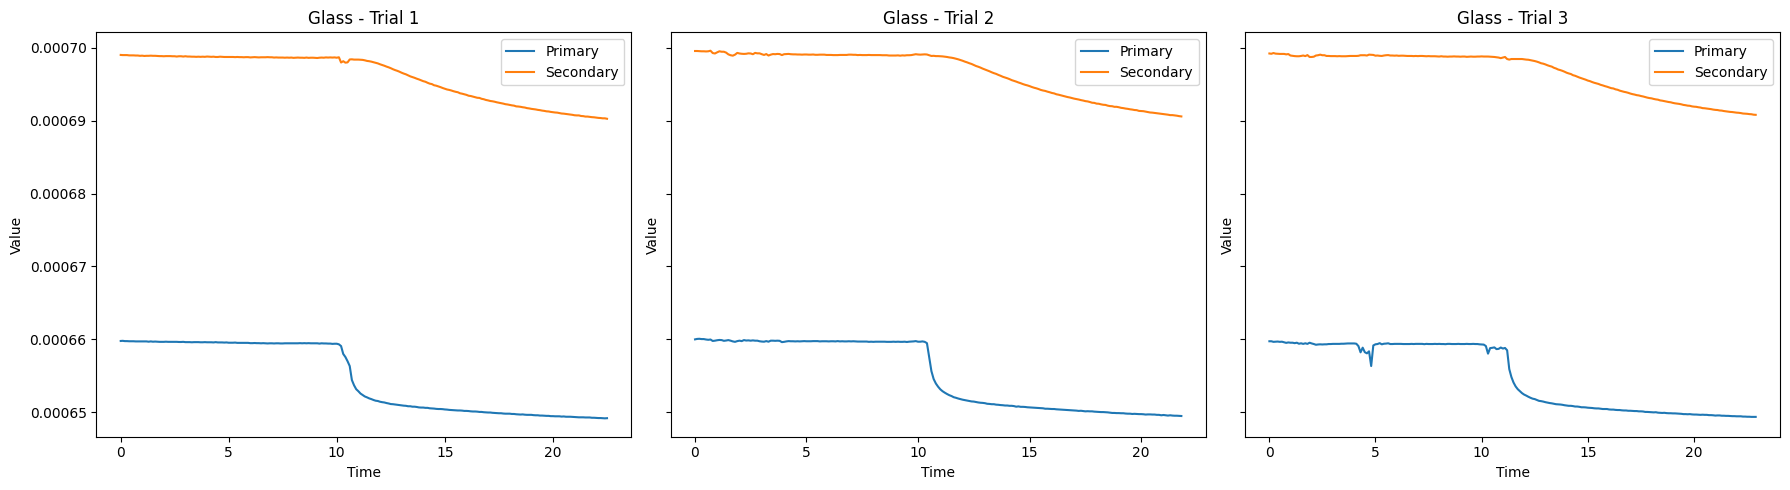

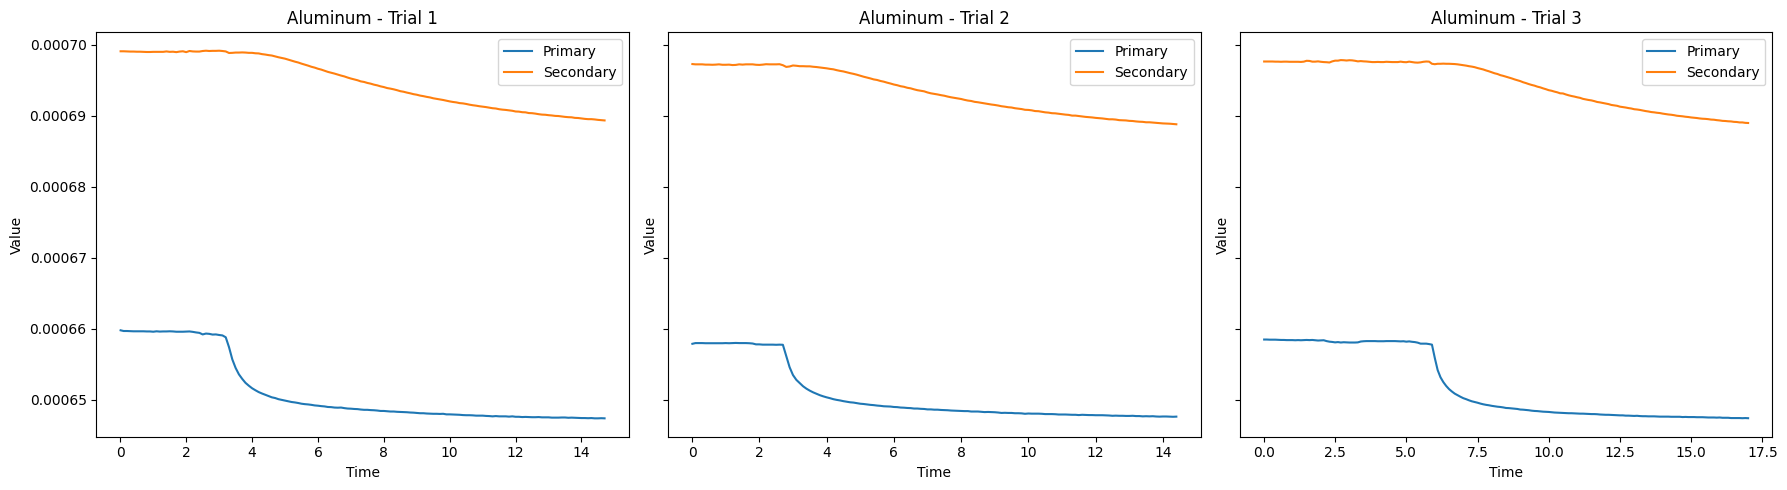

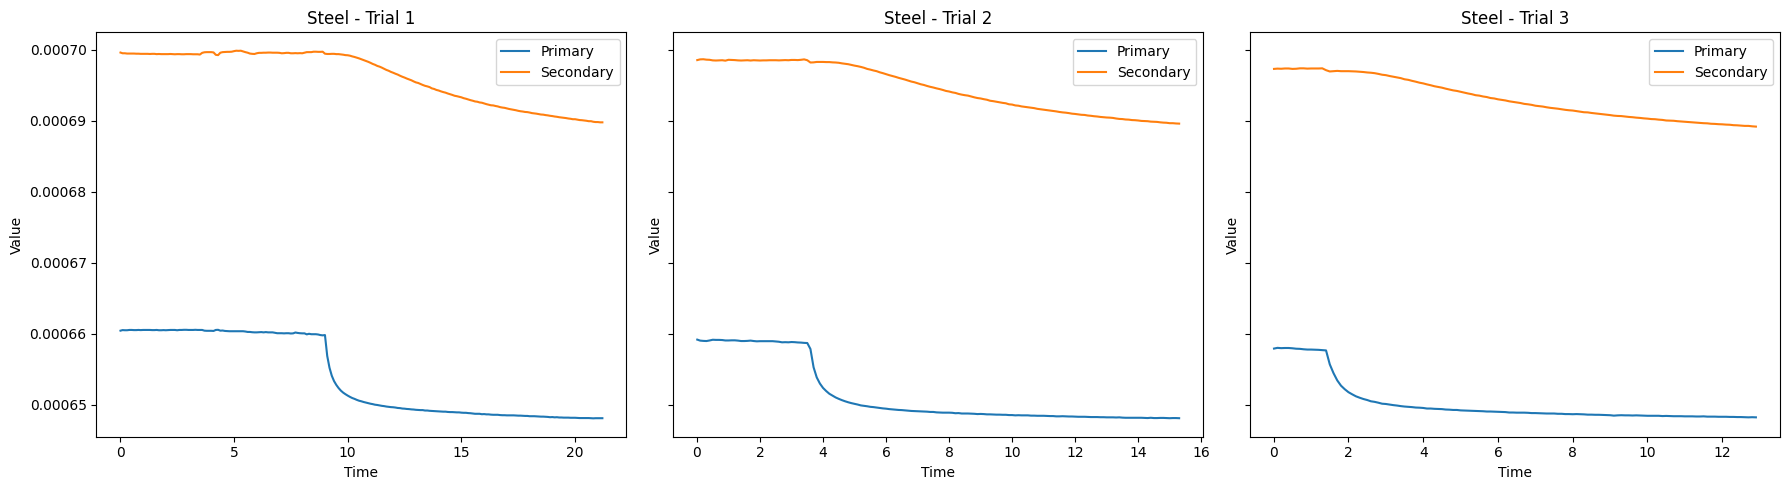

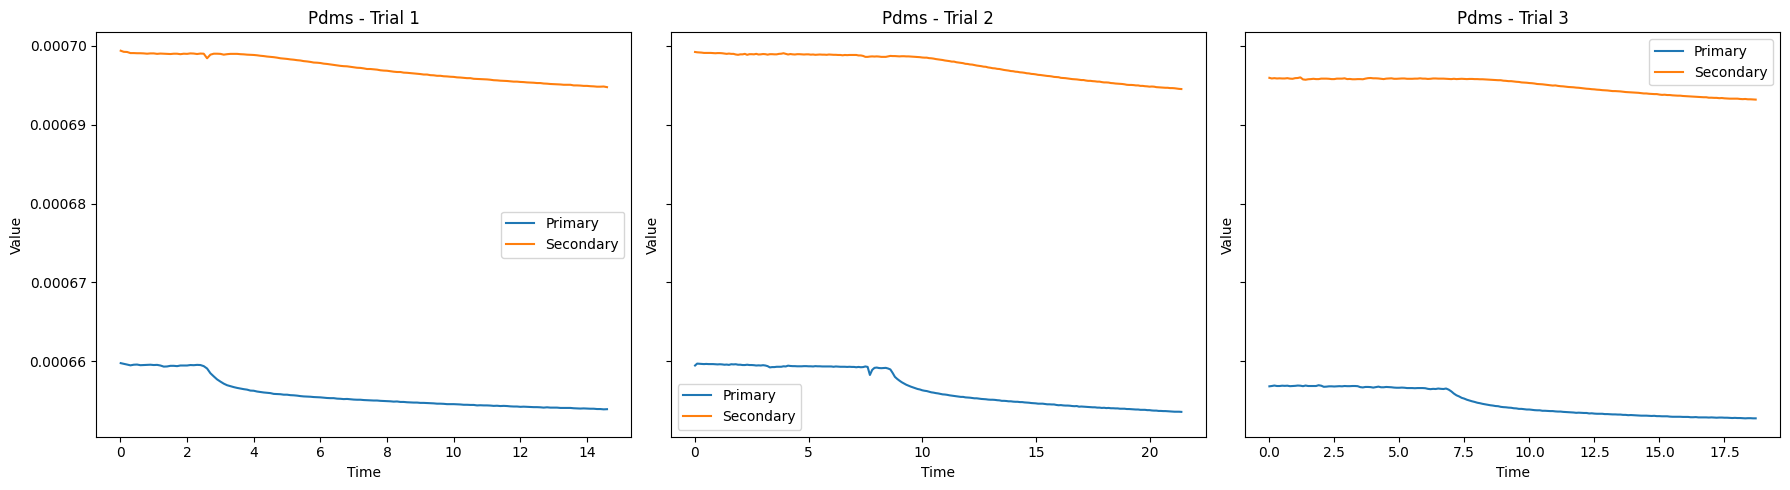

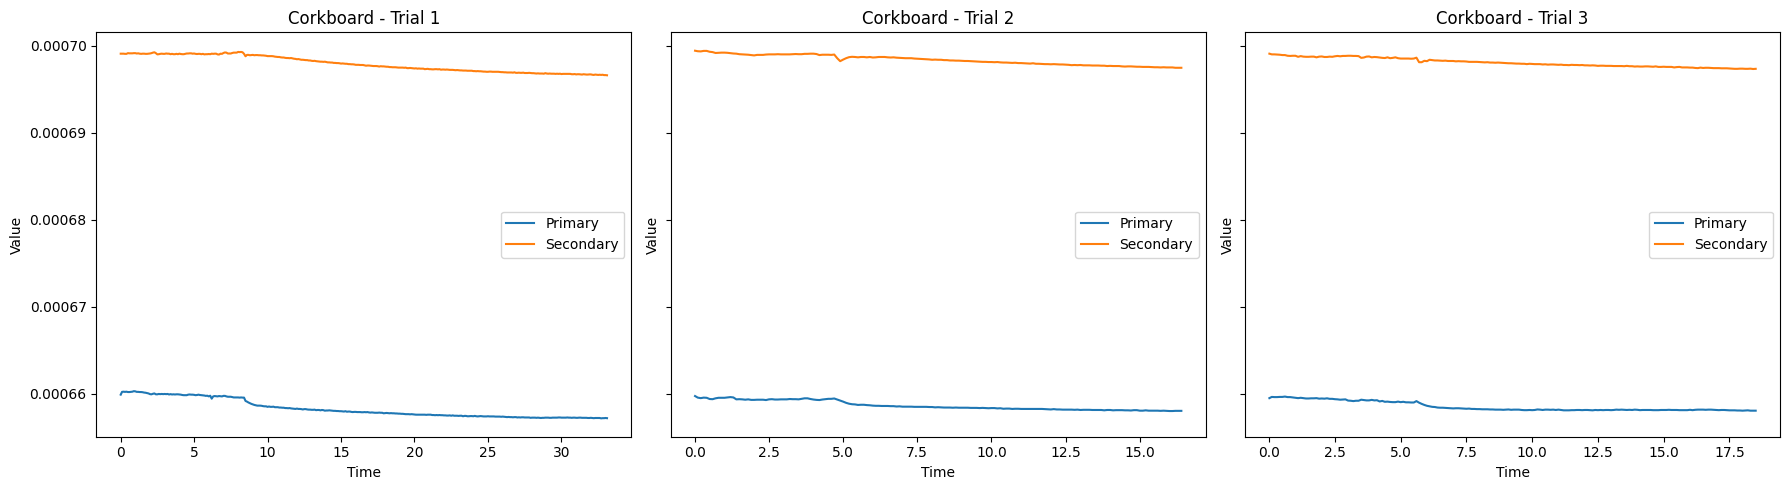

In [496]:
for m in materials:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

    for i, ax in enumerate(axes):
        subset = data[(data['Sample'] == m) & (data['Trial'] == i+1)]

        ax.plot(subset['Time'].values, subset['Primary'], label='Primary')
        ax.plot(subset['Time'].values, subset['Secondary'], label='Secondary')
        ax.set_xlabel('Time')

        ax.set_ylabel('Value')
        ax.set_title(f'{m.capitalize()} - Trial {i+1}')
        ax.legend()

    plt.tight_layout()
    plt.show()

## Plot Primary-Secondary Differnce

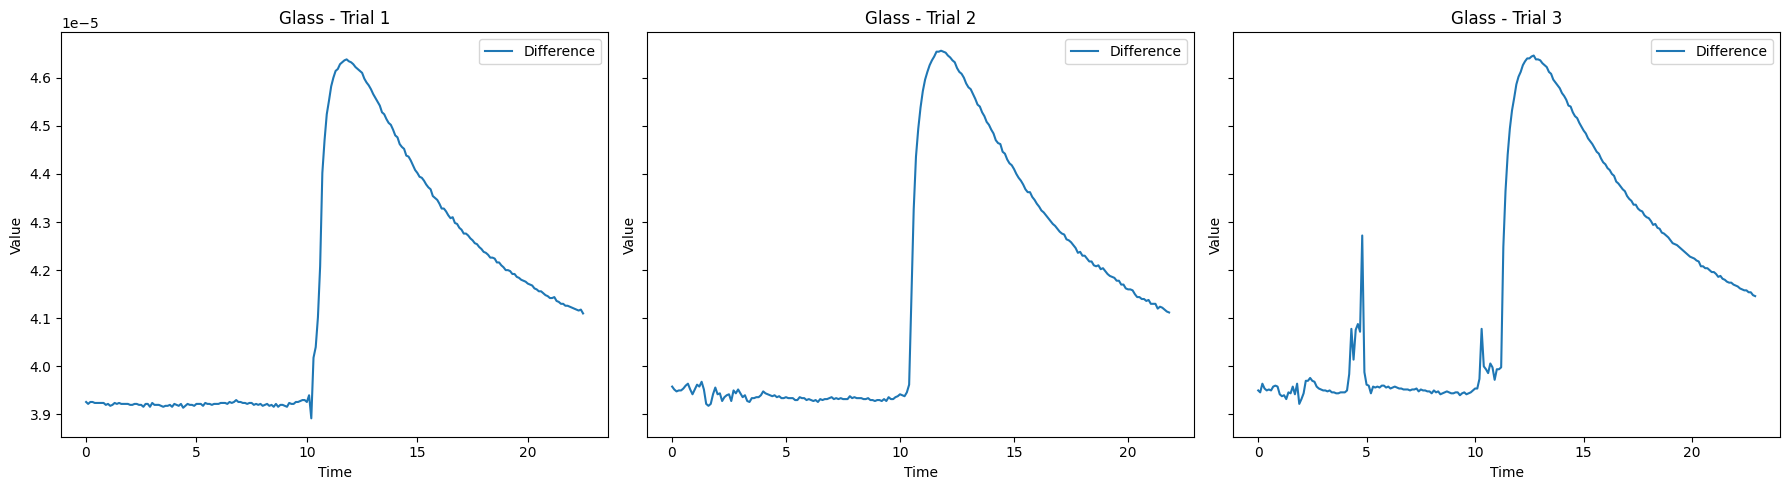

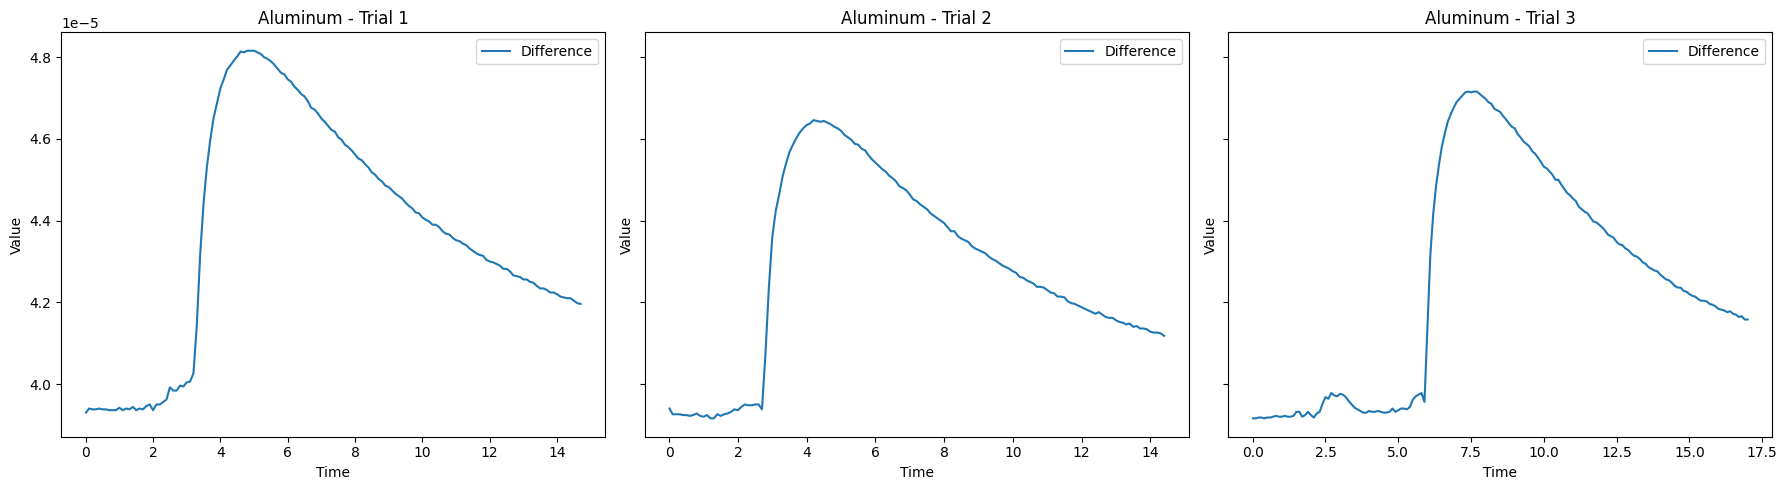

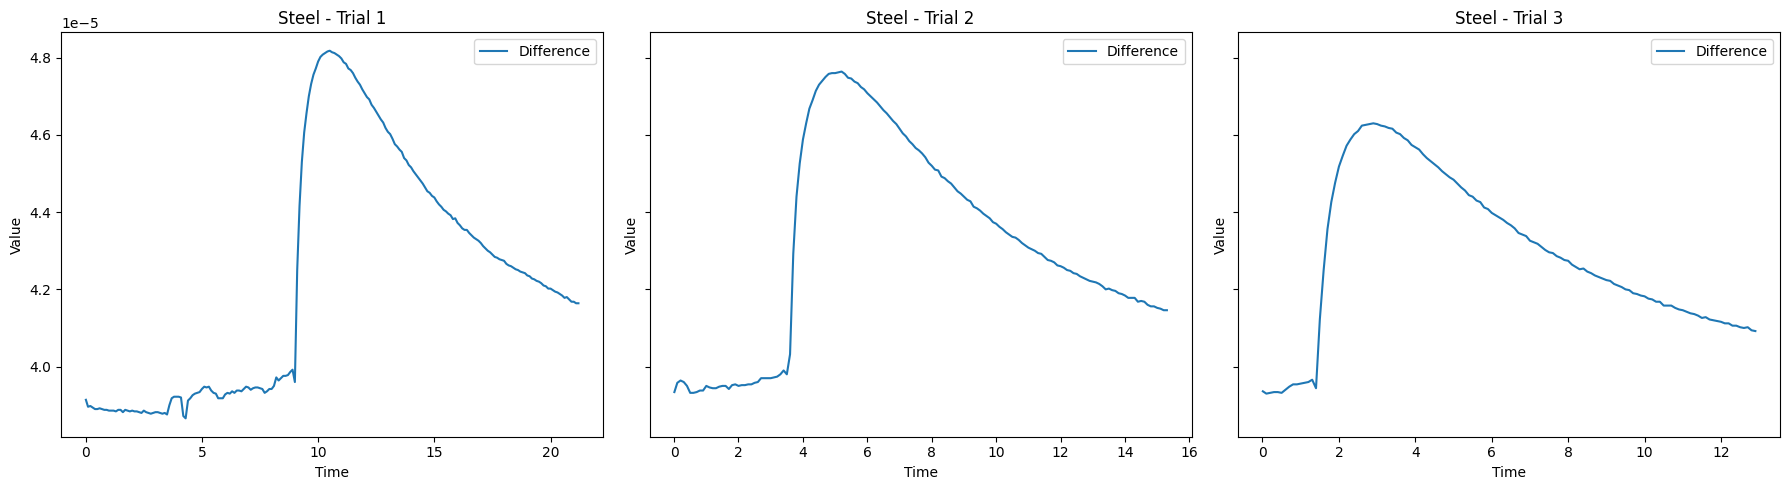

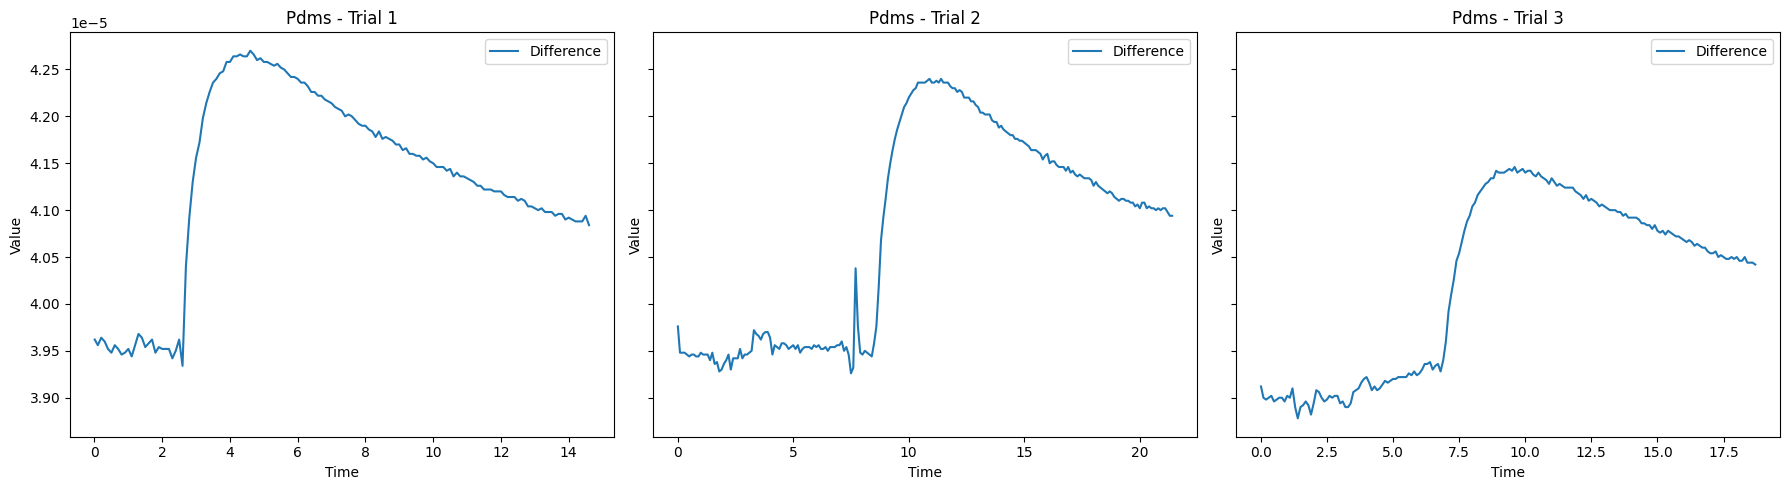

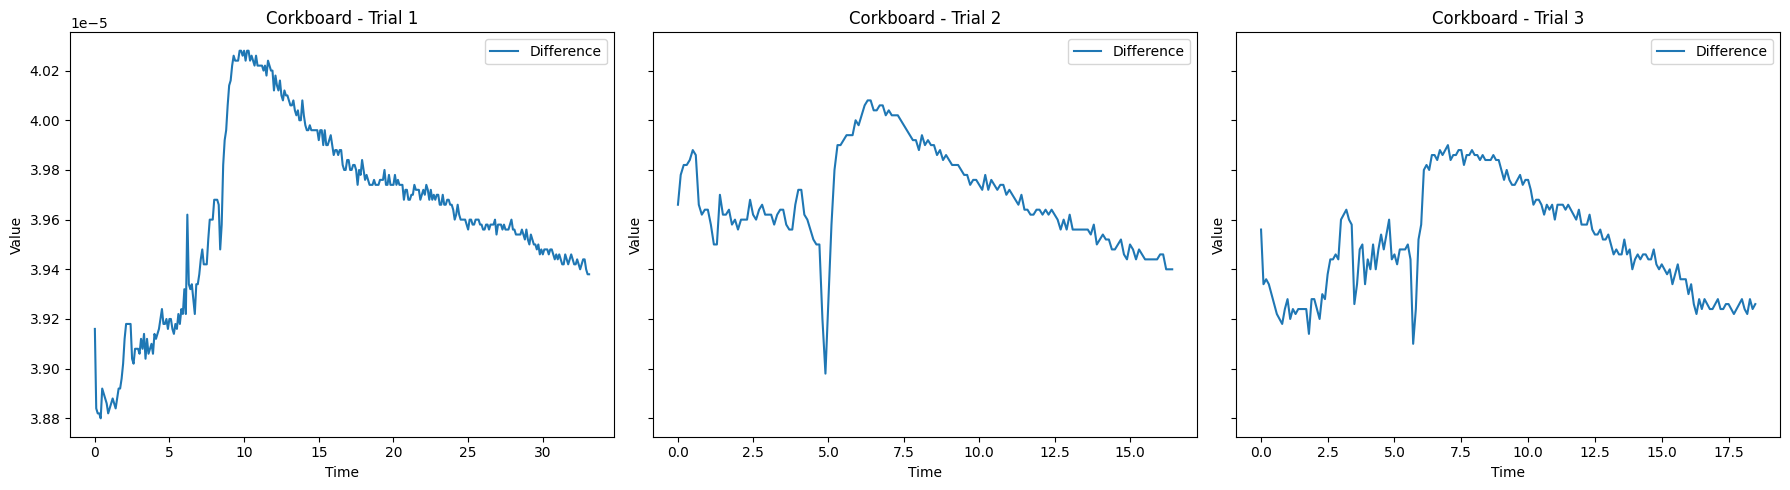

In [497]:
data['diff'] = data['Secondary'] - data['Primary']
data['abs_diff'] = data['diff'].abs()

# Plotting Primary and Secondary Readings Over Time
for m in materials:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

    for i, ax in enumerate(axes):
        subset = data[(data['Sample'] == m) & (data['Trial'] == i+1)]

        ax.plot(subset['Time'].values, subset['diff'], label='Difference')
        ax.set_xlabel('Time')

        ax.set_ylabel('Value')
        ax.set_title(f'{m.capitalize()} - Trial {i+1}')
        ax.legend()

    plt.tight_layout()
    plt.show()

# Elbow Finder

In [498]:
import numpy as np
from scipy.signal import savgol_filter

def find_global_first_elbow(
    subset,
    time_col="Time",
    signal_col="Primary",
    smooth_window=15,
    polyorder=2,
    pre_search_window=30,
    threshold_frac=0.15,
    direction="drop"
):
    """
    Finds elbow by first locating the strongest global slope change,
    then searching backward to find the clean start of the elbow.
    """

    df = subset.sort_values(time_col).copy()

    t = df[time_col].to_numpy(dtype=float)
    y = df[signal_col].to_numpy(dtype=float)

    mask = np.isfinite(t) & np.isfinite(y)
    t = t[mask]
    y = y[mask]

    n = len(y)

    if n < 10:
        return np.nan, np.nan, None

    # Make SavGol window valid
    smooth_window = min(smooth_window, n - 1 if n % 2 == 0 else n)

    if smooth_window % 2 == 0:
        smooth_window -= 1

    if smooth_window <= polyorder:
        smooth_window = polyorder + 3
        if smooth_window % 2 == 0:
            smooth_window += 1

    # Smooth signal
    y_smooth = savgol_filter(y, window_length=smooth_window, polyorder=polyorder)

    # Derivative
    dy = np.gradient(y_smooth, t)

    # Find strongest global slope
    if direction == "drop":
        peak_idx = np.argmin(dy)
        strongest_slope = dy[peak_idx]
        threshold = threshold_frac * strongest_slope  # negative value
        active = dy < threshold

    elif direction == "rise":
        peak_idx = np.argmax(dy)
        strongest_slope = dy[peak_idx]
        threshold = threshold_frac * strongest_slope
        active = dy > threshold

    else:
        raise ValueError("direction must be 'drop' or 'rise'")

    # Search backward from strongest slope to find start of elbow
    start_idx = peak_idx

    for j in range(peak_idx, 0, -1):
        if not active[j]:
            start_idx = j + 1
            break

    # Optional refinement: search only near the strongest slope region
    start_idx = max(0, start_idx)

    return t[start_idx], y[start_idx], start_idx

glass - Trial 0 - 101
glass - Trial 1 - 101
glass - Trial 2 - 109


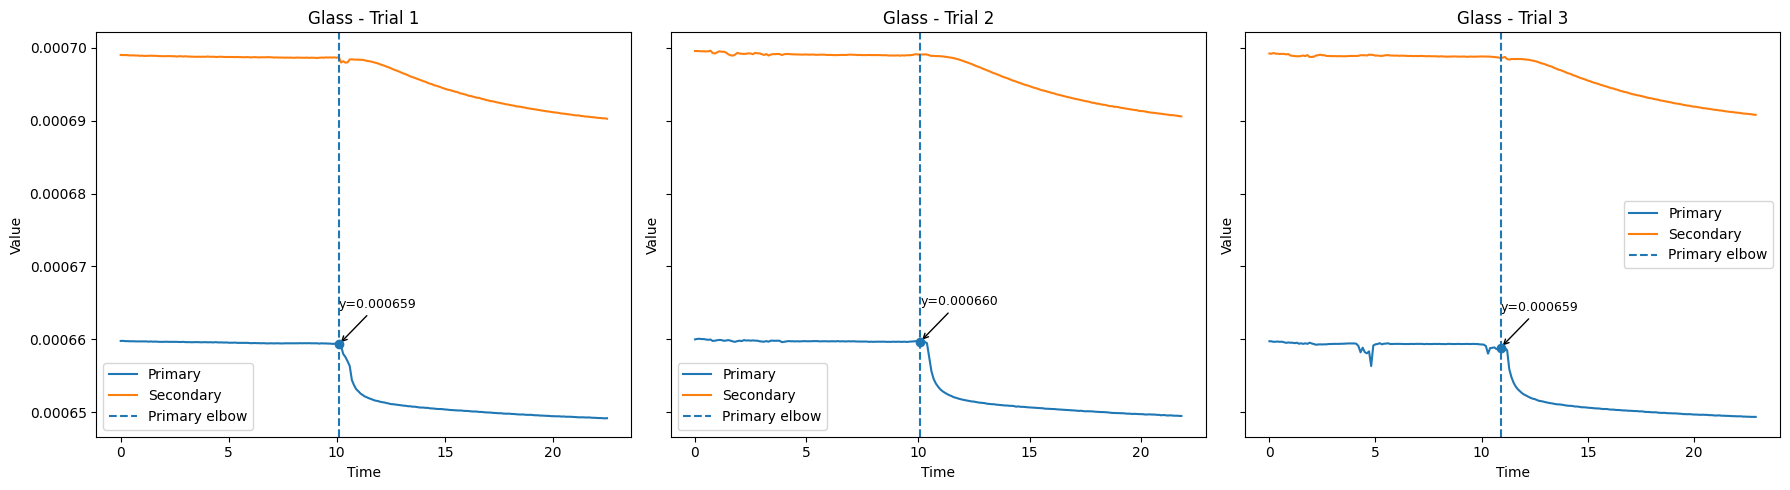

aluminum - Trial 0 - 30
aluminum - Trial 1 - 25
aluminum - Trial 2 - 56


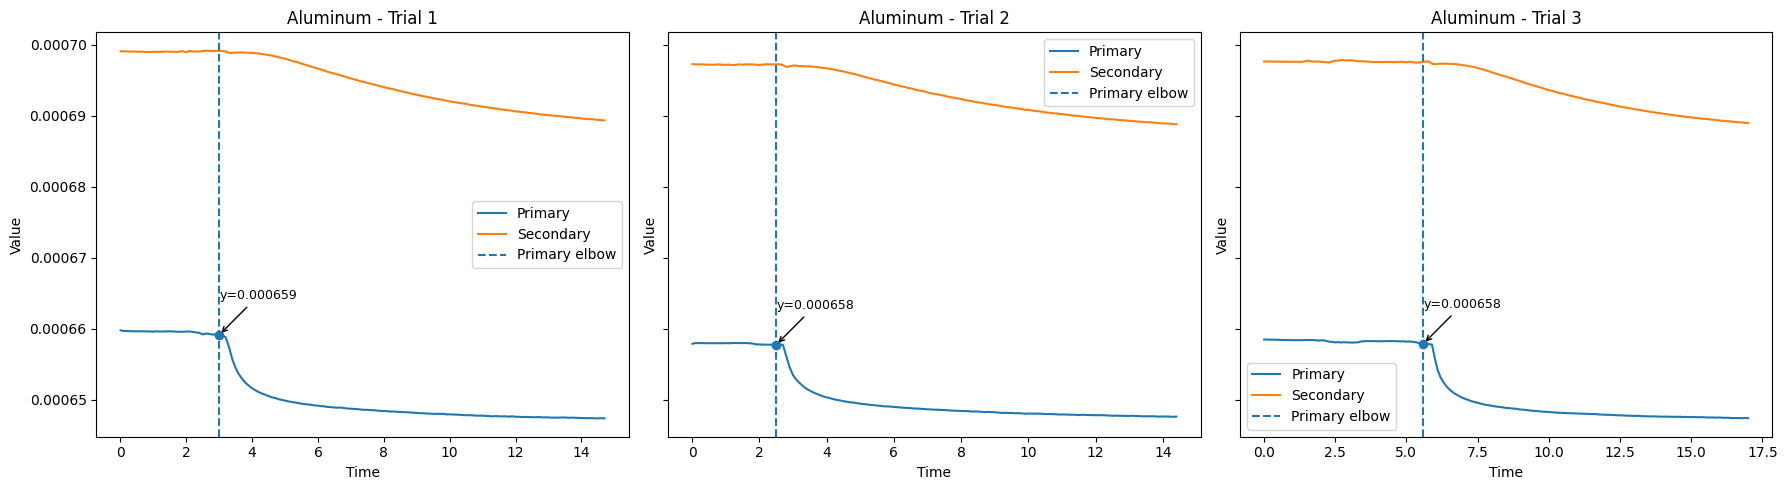

steel - Trial 0 - 87
steel - Trial 1 - 33
steel - Trial 2 - 12


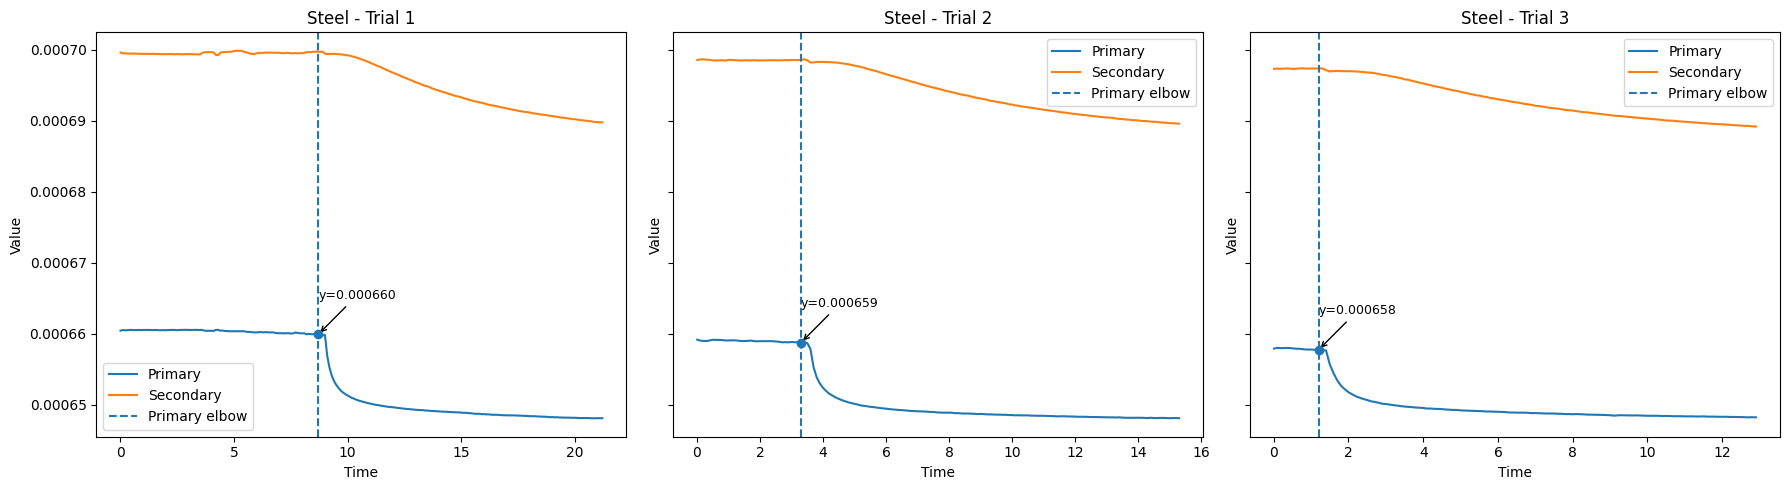

pdms - Trial 0 - 23
pdms - Trial 1 - 84
pdms - Trial 2 - 67


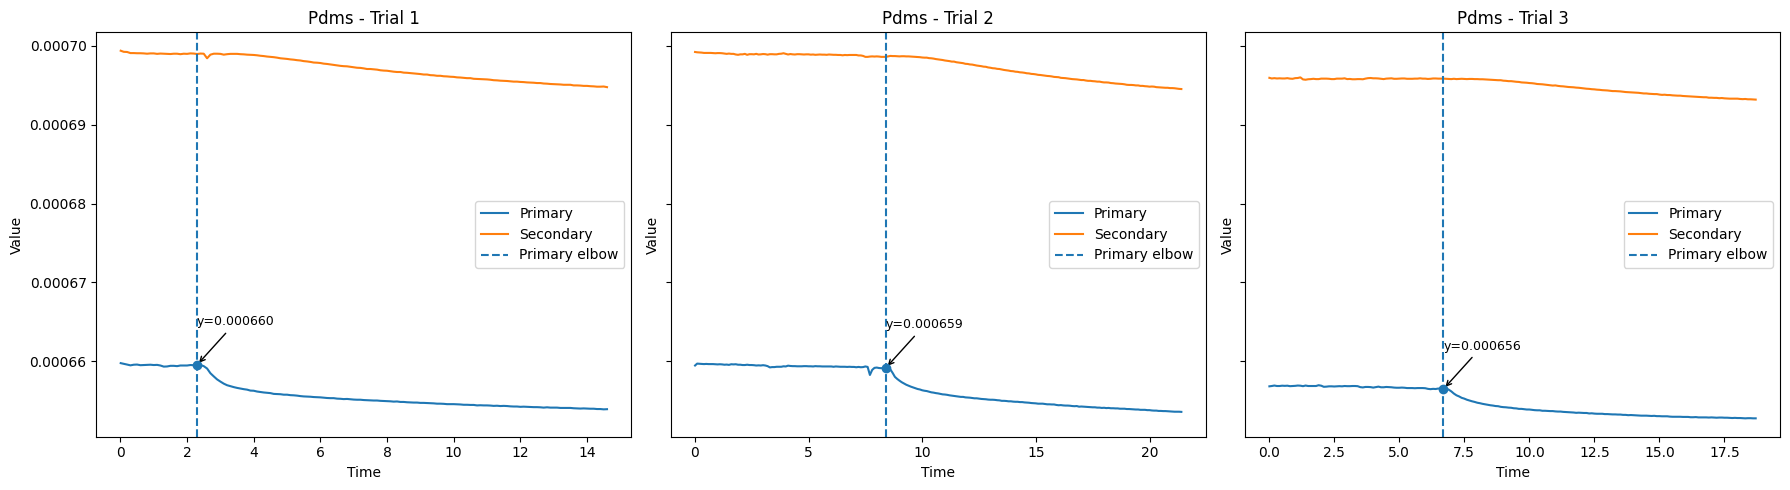

corkboard - Trial 0 - 81
corkboard - Trial 1 - 47
corkboard - Trial 2 - 54


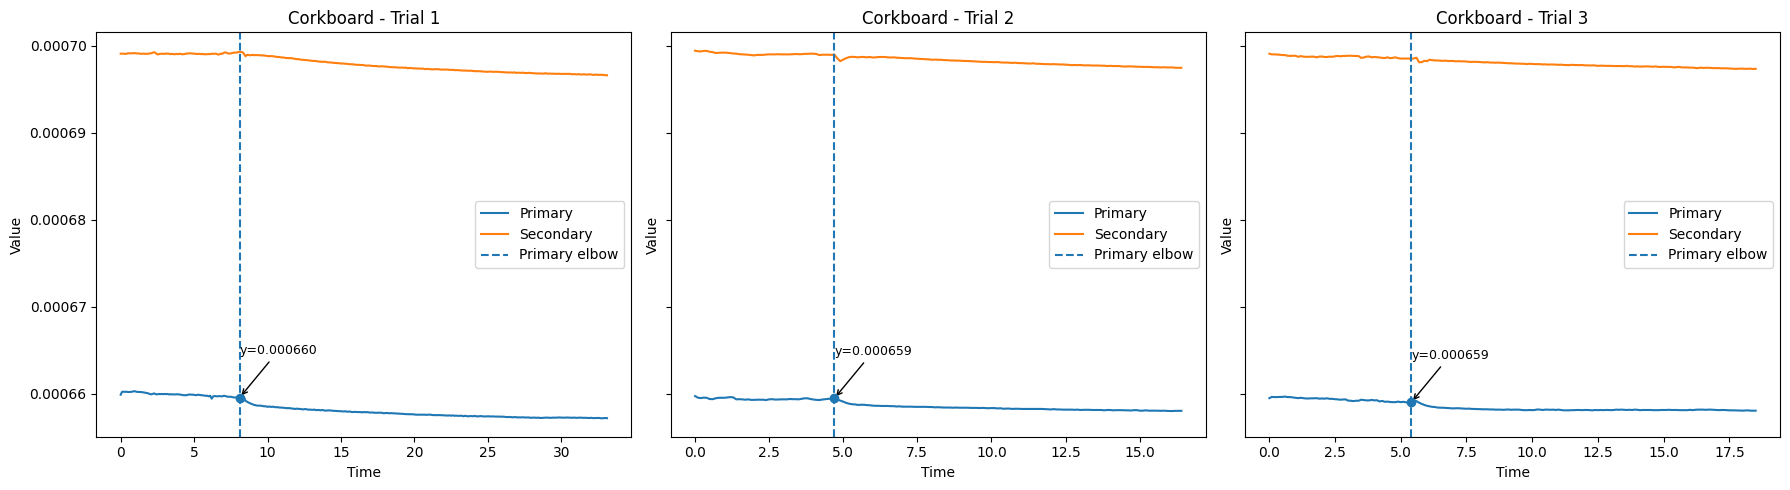

In [499]:
elbow_loc = {}
for m in materials:
    elbow_trials = {}
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

    for i, ax in enumerate(axes):
        subset = data[(data['Sample'] == m) & (data['Trial'] == i+1)].copy()
        subset = subset.sort_values('Time')

        elbow_time, elbow_value, elbow_idx = find_global_first_elbow(
            subset,
            time_col="Time",
            signal_col="Primary",
            smooth_window=15,
            polyorder=2,
            threshold_frac=0.3,
            direction="drop"
        )
        elbow_trials[i+1] = elbow_idx

        print(f"{m} - Trial {i} - {elbow_idx}")

        ax.plot(subset['Time'].values, subset['Primary'].values, label='Primary')
        ax.plot(subset['Time'].values, subset['Secondary'].values, label='Secondary')

        if not np.isnan(elbow_time):
            ax.axvline(elbow_time, linestyle='--', label='Primary elbow')
            ax.scatter(elbow_time, elbow_value, zorder=5)

            ax.annotate(
                f"y={elbow_value:.6f}",
                xy=(elbow_time, elbow_value),
                xytext=(elbow_time, elbow_value + 0.000005),
                arrowprops=dict(arrowstyle="->"),
                fontsize=9
            )

        ax.set_xlabel('Time')
        ax.set_ylabel('Value')
        ax.set_title(f'{m.capitalize()} - Trial {i+1}')
        ax.legend()
    elbow_loc[m] = elbow_trials
    

    plt.tight_layout()
    plt.show()

glass - Trial 1 - 102
glass - Trial 2 - 105
glass - Trial 3 - 113


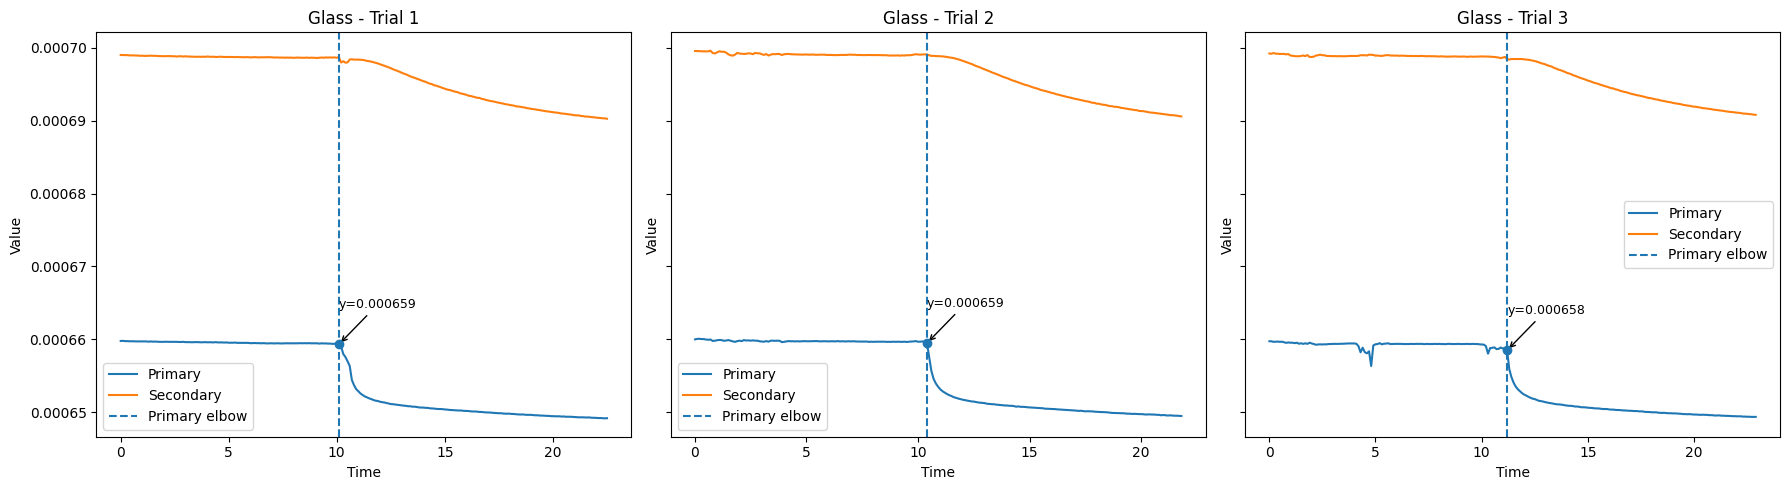

aluminum - Trial 1 - 33
aluminum - Trial 2 - 28
aluminum - Trial 3 - 60


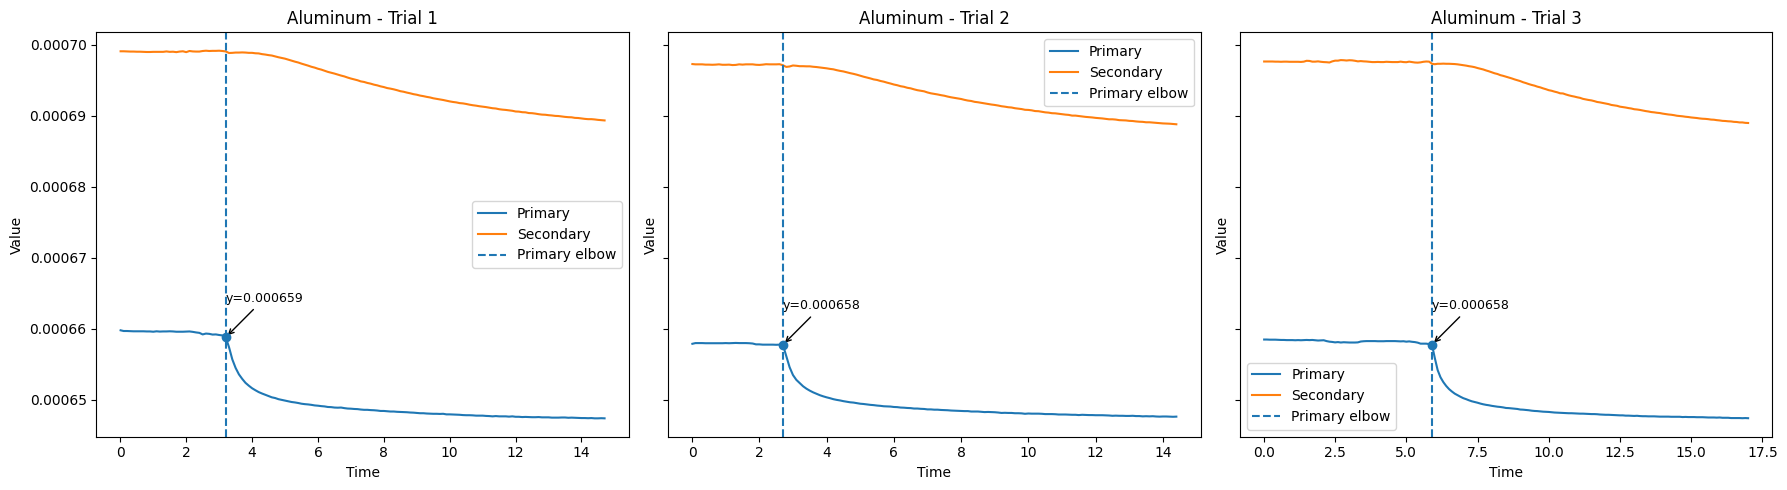

steel - Trial 1 - 91
steel - Trial 2 - 37
steel - Trial 3 - 15


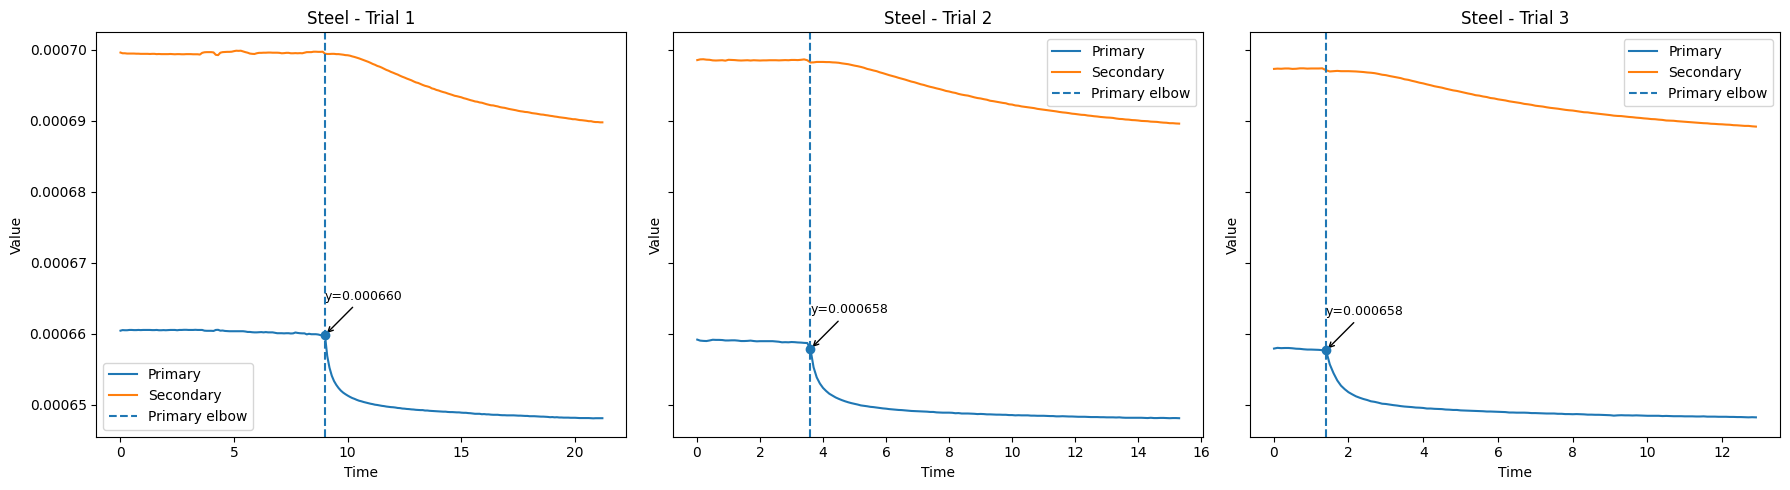

pdms - Trial 1 - 26
pdms - Trial 2 - 85
pdms - Trial 3 - 70


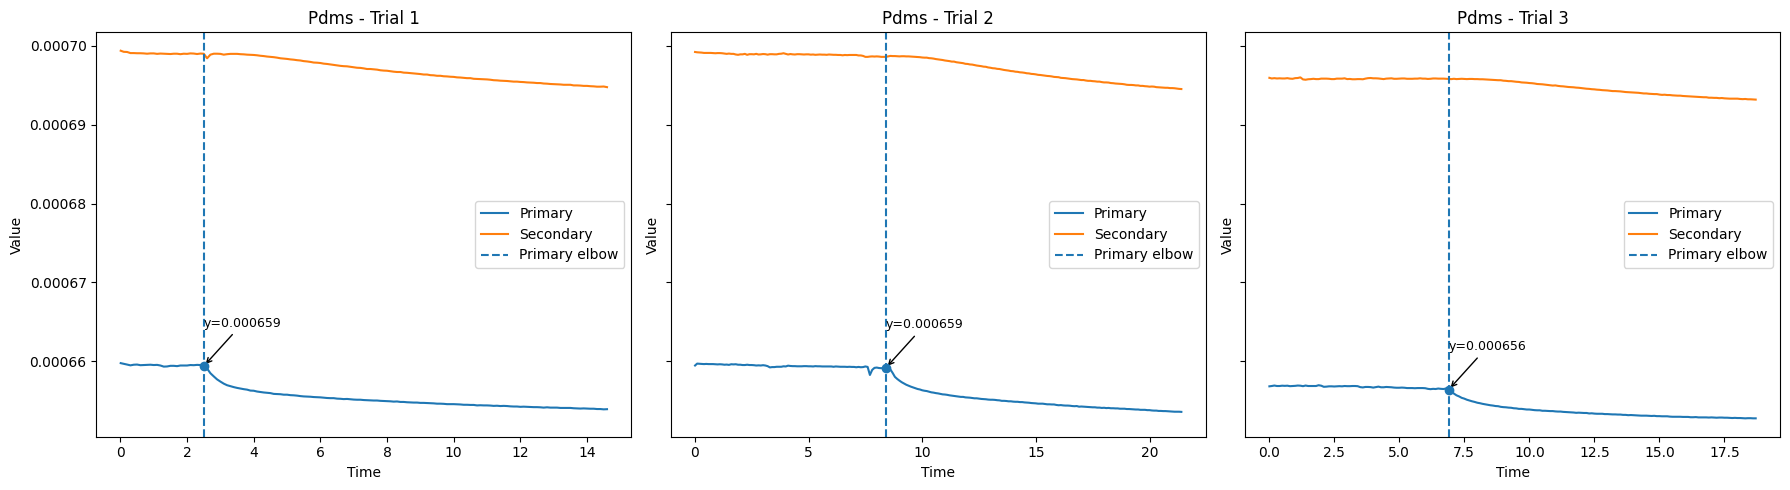

corkboard - Trial 1 - 84
corkboard - Trial 2 - 48
corkboard - Trial 3 - 57


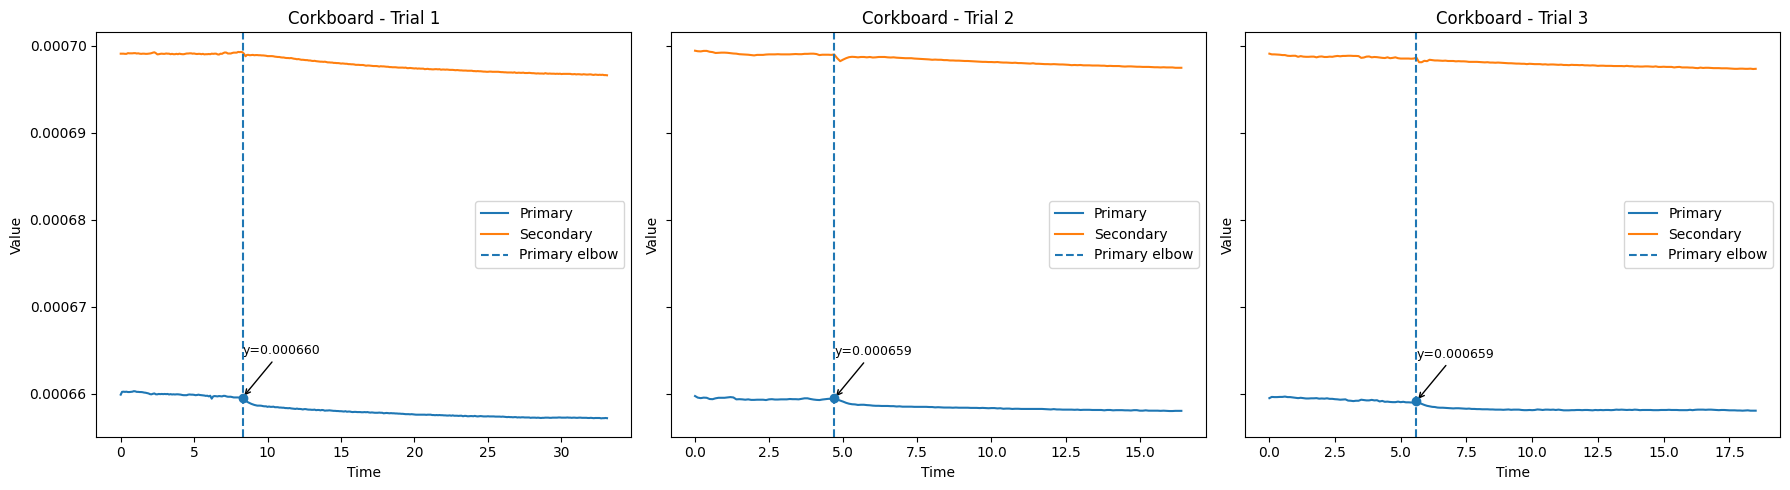

In [500]:
elbow_loc['glass'][1] = 102
elbow_loc['glass'][2] = 105
elbow_loc['glass'][3] = 113

elbow_loc['aluminum'][1] = 33
elbow_loc['aluminum'][2] = 28
elbow_loc['aluminum'][3] = 60

elbow_loc['steel'][1] = 91
elbow_loc['steel'][2] = 37
elbow_loc['steel'][3] = 15

elbow_loc['pdms'][1] = 26
elbow_loc['pdms'][2] = 85
elbow_loc['pdms'][3] = 70


elbow_loc['corkboard'][1] = 84
elbow_loc['corkboard'][2] = 48
elbow_loc['corkboard'][3] = 57

for m, elbows in elbow_loc.items():

    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

    for plot_idx, (i, elbow_idx) in enumerate(elbows.items()):
        ax = axes[plot_idx]

        subset = data[(data['Sample'] == m) & (data['Trial'] == i)].copy()
        subset = subset.sort_values('Time')

        elbow_time = subset.loc[subset['index'] == elbow_idx, 'Time'].values[0]
        elbow_value = subset.loc[subset['index'] == elbow_idx, 'Primary'].values[0]

        print(f"{m} - Trial {i} - {elbow_idx}")

        ax.plot(subset['Time'].values, subset['Primary'].values, label='Primary')
        ax.plot(subset['Time'].values, subset['Secondary'].values, label='Secondary')

        if not np.isnan(elbow_time):
            ax.axvline(elbow_time, linestyle='--', label='Primary elbow')
            ax.scatter(elbow_time, elbow_value, zorder=5)

            ax.annotate(
                f"y={elbow_value:.6f}",
                xy=(elbow_time, elbow_value),
                xytext=(elbow_time, elbow_value + 0.000005),
                arrowprops=dict(arrowstyle="->"),
                fontsize=9
            )

        ax.set_xlabel('Time')
        ax.set_ylabel('Value')
        ax.set_title(f'{m.capitalize()} - Trial {i}')
        ax.legend()
    
    plt.tight_layout()
    plt.show()

In [501]:
data["is_elbow"] = False
data["filter"] = False

for (sample, trial), subset in data.groupby(["Sample", "Trial"]):

    elbow_idx = elbow_loc[sample][trial]
    elbow_time = subset.loc[subset['index'] == elbow_idx, 'Time'].values[0]
    elbow_value = subset.loc[subset['index'] == elbow_idx, 'Primary'].values[0]

    print(f"{sample} - Trial {trial} - {elbow_idx}")

    data.loc[(data['Sample'] == sample) & (data['Trial'].astype(int) == int(trial)) & (data['index'] >= elbow_idx), 'filter'] = True
    data.loc[(data['Sample'] == sample) & (data['Trial'].astype(int) == int(trial)) & (data['index'] >= elbow_idx), 'elbow_time'] = elbow_time
    data.loc[(data['Sample'] == sample) & (data['Trial'].astype(int) == int(trial)) & (data['index'] >= elbow_idx), 'elbow_idx'] = elbow_idx

    if not np.isnan(elbow_time):
        # find the actual row in the original dataframe closest to the elbow time
        elbow_row_idx = subset["Time"].sub(elbow_time).abs().idxmin()

        data.loc[elbow_row_idx, "is_elbow"] = True
        data.loc[elbow_row_idx, "elbow_time"] = elbow_time
        data.loc[elbow_row_idx, "elbow_value"] = elbow_value

data = data[data['filter']]
data['Time'] = data['Time'] - data['elbow_time']
data['index'] = data['index'] - data['elbow_idx']
data = data[data['index'] < 100]

aluminum - Trial 1.0 - 33
aluminum - Trial 2.0 - 28
aluminum - Trial 3.0 - 60
corkboard - Trial 1.0 - 84
corkboard - Trial 2.0 - 48
corkboard - Trial 3.0 - 57
glass - Trial 1.0 - 102
glass - Trial 2.0 - 105
glass - Trial 3.0 - 113
pdms - Trial 1.0 - 26
pdms - Trial 2.0 - 85
pdms - Trial 3.0 - 70
steel - Trial 1.0 - 91
steel - Trial 2.0 - 37
steel - Trial 3.0 - 15


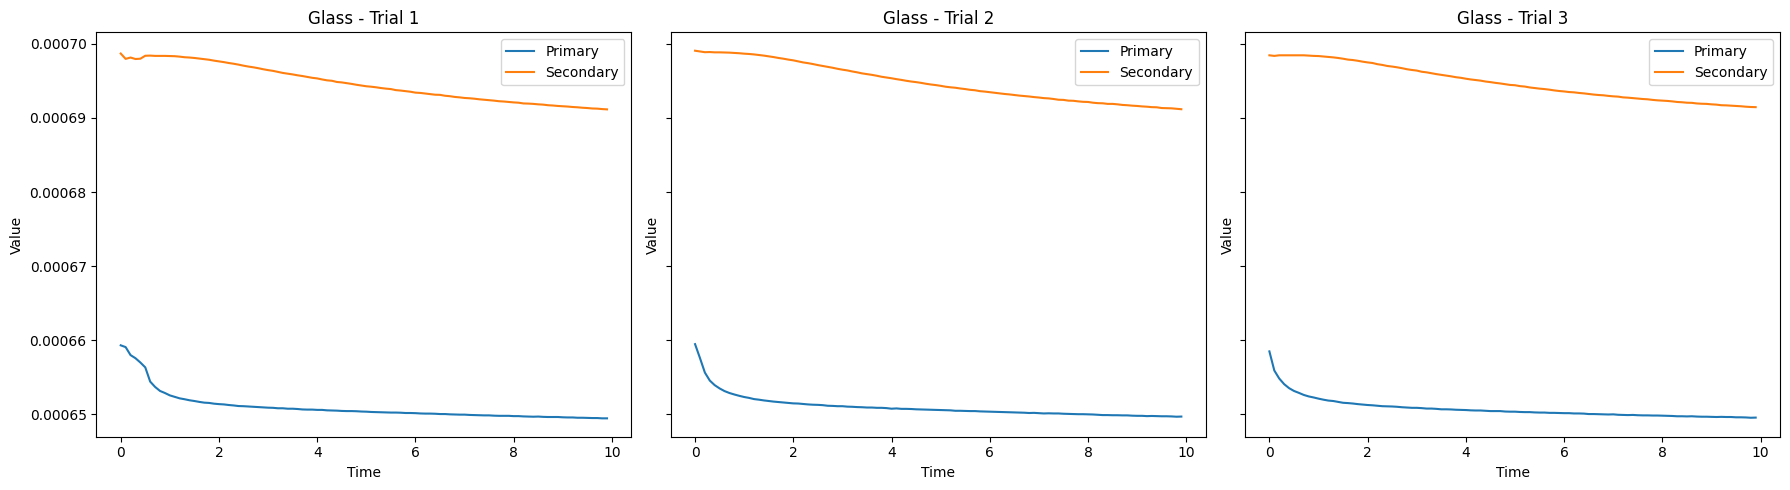

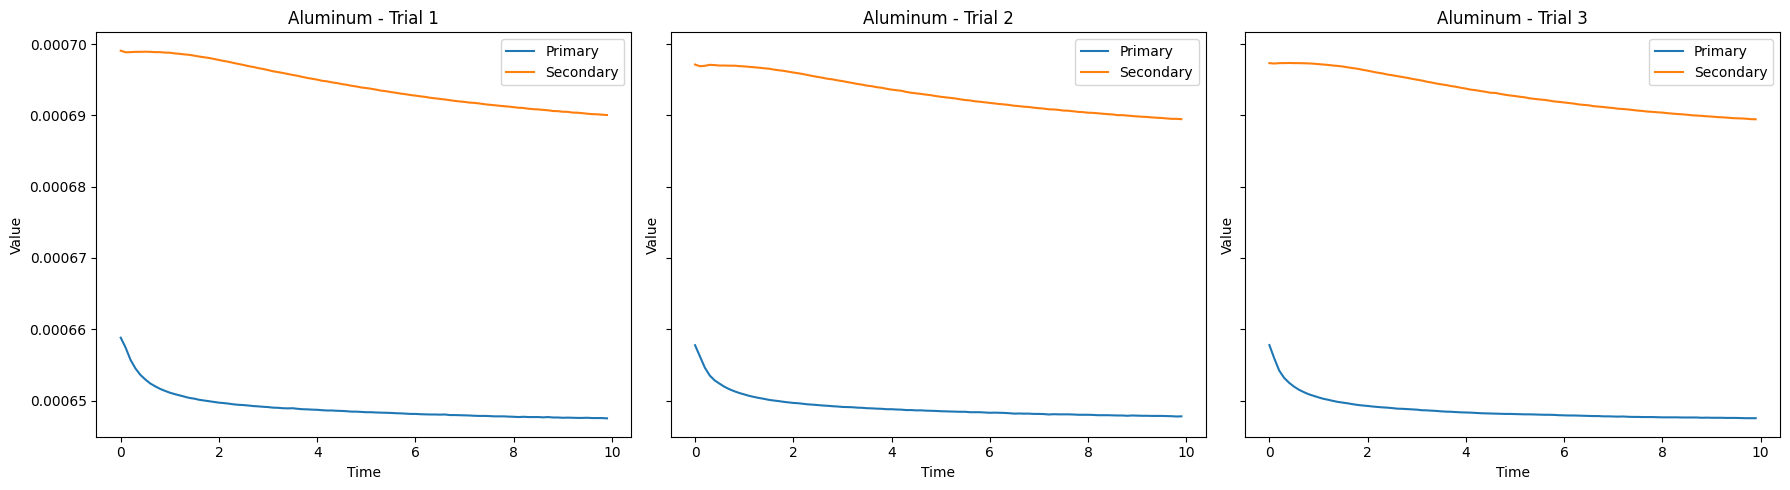

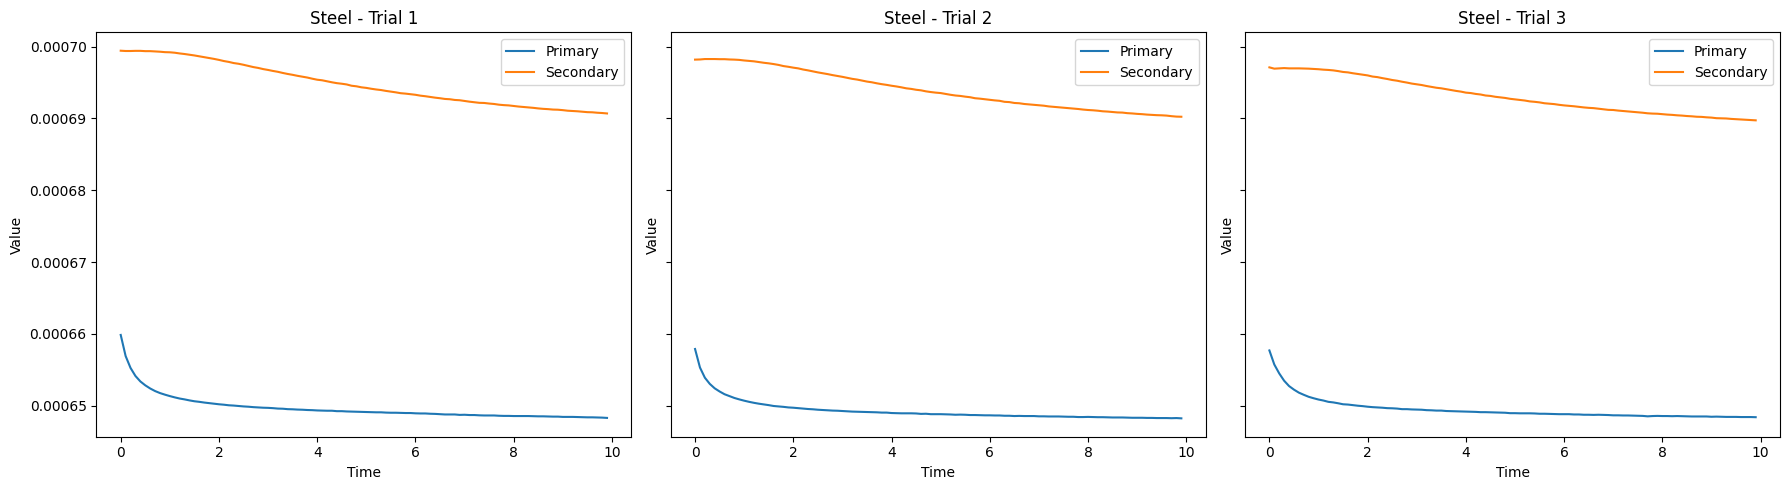

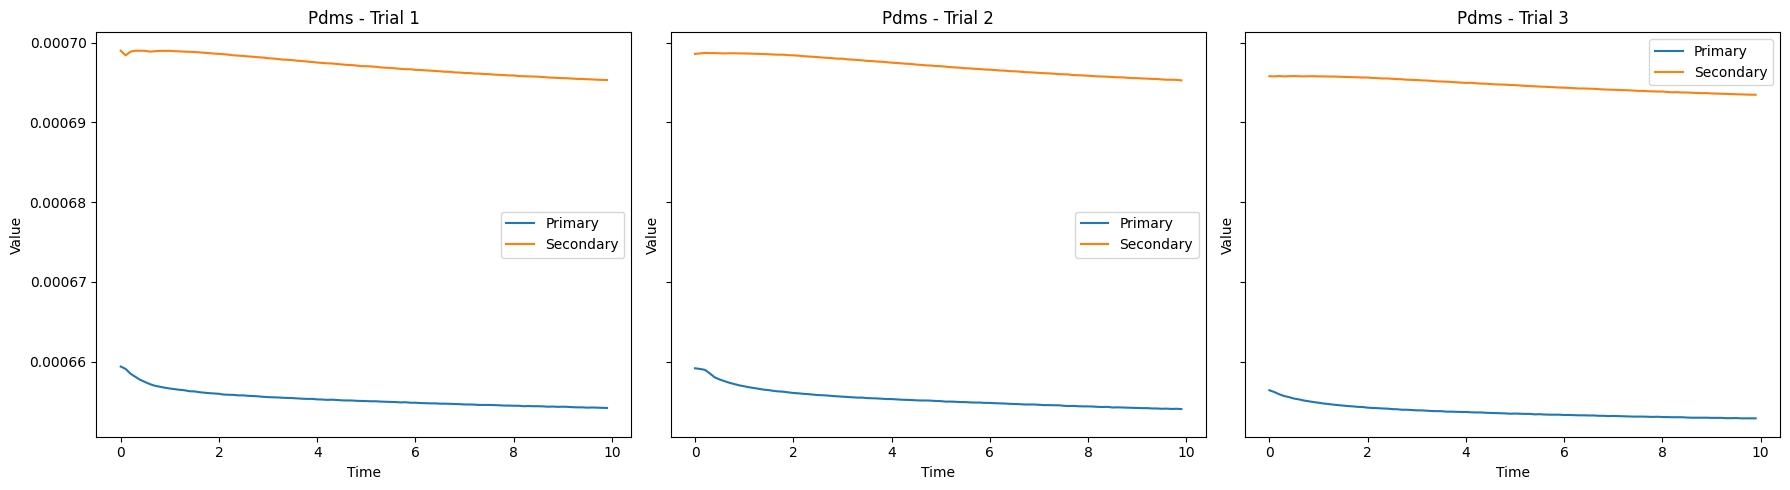

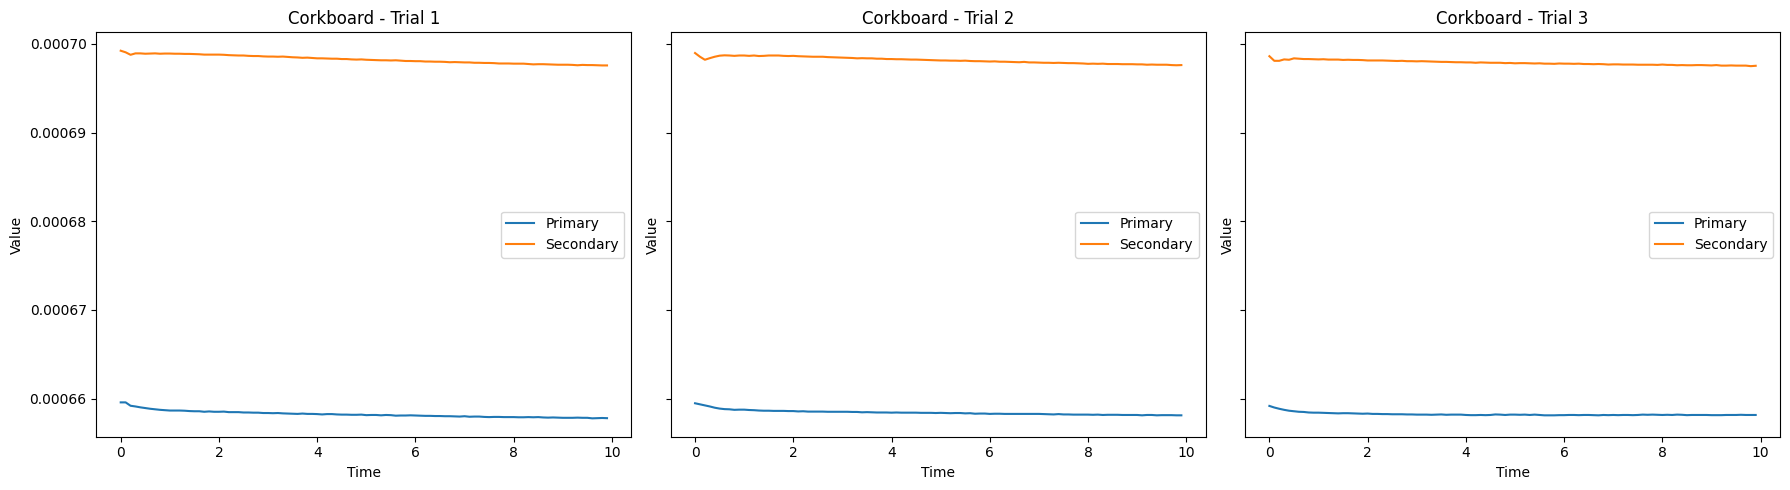

In [502]:
data = data[data['filter']]
for m in materials:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

    for i, ax in enumerate(axes):
        subset = data[(data['Sample'] == m) & (data['Trial'] == i+1)]

        ax.plot(subset['Time'].values, subset['Primary'], label='Primary')
        ax.plot(subset['Time'].values, subset['Secondary'], label='Secondary')
        ax.set_xlabel('Time')

        ax.set_ylabel('Value')
        ax.set_title(f'{m.capitalize()} - Trial {i+1}')
        ax.legend()

    plt.tight_layout()
    plt.show()

# Manual Extraction

In [503]:
def forced_slope_from_elbow(time_aligned, signal_change, slope_window=1.0):
    # Use only early post-elbow region
    mask = (time_aligned >= 0) & (time_aligned <= slope_window)

    # Fallback if fewer than 3 points are inside the slope window
    if mask.sum() < 3:
        mask = np.arange(len(time_aligned)) < 5

    x = time_aligned[mask]
    y = signal_change[mask]

    denominator = np.sum(x**2)

    if denominator == 0:
        return np.nan

    # Linear fit forced through elbow/origin:
    # y = m*x
    slope = np.sum(x * y) / denominator

    return slope


def auc_in_window(time_aligned, signal_abs_change, window):
    mask = (time_aligned >= 0) & (time_aligned <= window)

    if mask.sum() < 2:
        return np.nan

    return trapezoid(signal_abs_change[mask], time_aligned[mask])


def slope_in_window(time_aligned, signal_change, window):
    mask = (time_aligned >= 0) & (time_aligned <= window)

    if mask.sum() < 3:
        return np.nan

    x = time_aligned[mask]
    y = signal_change[mask]

    denominator = np.sum(x**2)

    if denominator == 0:
        return np.nan

    return np.sum(x * y) / denominator


def time_to_percent(time_aligned, signal_abs_change, percent):
    peak_change = np.nanmax(signal_abs_change)

    if peak_change == 0 or np.isnan(peak_change):
        return np.nan

    target = percent * peak_change

    idx = np.where(signal_abs_change >= target)[0]

    if len(idx) == 0:
        return np.nan

    return time_aligned[idx[0]]


def derivative_features(time_aligned, signal_change):
    if len(time_aligned) < 3:
        return {
            "max_derivative": np.nan,
            "time_of_max_derivative": np.nan,
            "mean_derivative_0_1s": np.nan,
            "mean_derivative_0_2s": np.nan,
            "mean_derivative_0_5s": np.nan,
        }

    # Avoid division issues if time has duplicates
    if len(np.unique(time_aligned)) < 3:
        return {
            "max_derivative": np.nan,
            "time_of_max_derivative": np.nan,
            "mean_derivative_0_1s": np.nan,
            "mean_derivative_0_2s": np.nan,
            "mean_derivative_0_5s": np.nan,
        }

    derivative = np.gradient(signal_change, time_aligned)

    max_derivative_idx = np.argmax(np.abs(derivative))

    out = {
        "max_derivative": derivative[max_derivative_idx],
        "time_of_max_derivative": time_aligned[max_derivative_idx],
    }

    for window in [1, 2, 5]:
        mask = (time_aligned >= 0) & (time_aligned <= window)

        if mask.sum() >= 2:
            out[f"mean_derivative_0_{window}s"] = np.nanmean(derivative[mask])
        else:
            out[f"mean_derivative_0_{window}s"] = np.nan

    return out


def decay_slope_after_peak(time_aligned, signal_change, peak_time):
    mask = time_aligned >= peak_time

    if mask.sum() < 2:
        return np.nan

    x = time_aligned[mask]
    y = signal_change[mask]

    if x[-1] == x[0]:
        return np.nan

    return (y[-1] - y[0]) / (x[-1] - x[0])


def extract_trial_features(trial_data, slope_window=1.0):
    trial_data = trial_data.sort_values("Time").copy()

    time = trial_data["Time"].values
    primary = trial_data["Primary"].values
    secondary = trial_data["Secondary"].values

    # Difference signal
    difference = primary - secondary

    # First data point is assumed to be the elbow
    elbow_time = time[0]
    primary_elbow_value = primary[0]
    secondary_elbow_value = secondary[0]
    difference_elbow_value = difference[0]

    # Align time so elbow = 0
    time_aligned = time - elbow_time

    # Changes relative to elbow baseline
    primary_change = primary - primary_elbow_value
    secondary_change = secondary - secondary_elbow_value
    difference_change = difference - difference_elbow_value

    # Absolute distance from elbow baseline
    primary_abs_change = np.abs(primary_change)
    secondary_abs_change = np.abs(secondary_change)
    difference_abs_change = np.abs(difference_change)

    # Forced slopes from elbow
    primary_slope = forced_slope_from_elbow(
        time_aligned,
        primary_change,
        slope_window=slope_window
    )

    secondary_slope = forced_slope_from_elbow(
        time_aligned,
        secondary_change,
        slope_window=slope_window
    )

    difference_slope = forced_slope_from_elbow(
        time_aligned,
        difference_change,
        slope_window=slope_window
    )

    # Peak change from elbow baseline
    primary_peak_change = primary_abs_change.max()
    secondary_peak_change = secondary_abs_change.max()
    difference_peak_change = difference_abs_change.max()

    # Time to peak change
    primary_peak_idx = np.argmax(primary_abs_change)
    secondary_peak_idx = np.argmax(secondary_abs_change)
    difference_peak_idx = np.argmax(difference_abs_change)

    primary_peak_time = time_aligned[primary_peak_idx]
    secondary_peak_time = time_aligned[secondary_peak_idx]
    difference_peak_time = time_aligned[difference_peak_idx]

    # Lag features
    lag = secondary_peak_time - primary_peak_time
    difference_lag_from_primary = difference_peak_time - primary_peak_time
    difference_lag_from_secondary = difference_peak_time - secondary_peak_time

    # AUC features
    primary_auc = trapezoid(primary_abs_change, time_aligned)
    secondary_auc = trapezoid(secondary_abs_change, time_aligned)
    difference_auc = trapezoid(difference_abs_change, time_aligned)

    # Early AUC windows
    primary_auc_0_0p5s = auc_in_window(time_aligned, primary_abs_change, 0.5)
    primary_auc_0_1s = auc_in_window(time_aligned, primary_abs_change, 1.0)
    primary_auc_0_2s = auc_in_window(time_aligned, primary_abs_change, 2.0)
    primary_auc_0_5s = auc_in_window(time_aligned, primary_abs_change, 5.0)

    secondary_auc_0_0p5s = auc_in_window(time_aligned, secondary_abs_change, 0.5)
    secondary_auc_0_1s = auc_in_window(time_aligned, secondary_abs_change, 1.0)
    secondary_auc_0_2s = auc_in_window(time_aligned, secondary_abs_change, 2.0)
    secondary_auc_0_5s = auc_in_window(time_aligned, secondary_abs_change, 5.0)

    difference_auc_0_0p5s = auc_in_window(time_aligned, difference_abs_change, 0.5)
    difference_auc_0_1s = auc_in_window(time_aligned, difference_abs_change, 1.0)
    difference_auc_0_2s = auc_in_window(time_aligned, difference_abs_change, 2.0)
    difference_auc_0_5s = auc_in_window(time_aligned, difference_abs_change, 5.0)

    # Early slope windows
    primary_slope_0_0p5s = slope_in_window(time_aligned, primary_change, 0.5)
    primary_slope_0_1s = slope_in_window(time_aligned, primary_change, 1.0)
    primary_slope_0_2s = slope_in_window(time_aligned, primary_change, 2.0)
    primary_slope_0_5s = slope_in_window(time_aligned, primary_change, 5.0)

    secondary_slope_0_0p5s = slope_in_window(time_aligned, secondary_change, 0.5)
    secondary_slope_0_1s = slope_in_window(time_aligned, secondary_change, 1.0)
    secondary_slope_0_2s = slope_in_window(time_aligned, secondary_change, 2.0)
    secondary_slope_0_5s = slope_in_window(time_aligned, secondary_change, 5.0)

    difference_slope_0_0p5s = slope_in_window(time_aligned, difference_change, 0.5)
    difference_slope_0_1s = slope_in_window(time_aligned, difference_change, 1.0)
    difference_slope_0_2s = slope_in_window(time_aligned, difference_change, 2.0)
    difference_slope_0_5s = slope_in_window(time_aligned, difference_change, 5.0)

    # Time-to-percent features
    primary_time_to_10 = time_to_percent(time_aligned, primary_abs_change, 0.10)
    primary_time_to_25 = time_to_percent(time_aligned, primary_abs_change, 0.25)
    primary_time_to_50 = time_to_percent(time_aligned, primary_abs_change, 0.50)
    primary_time_to_75 = time_to_percent(time_aligned, primary_abs_change, 0.75)
    primary_time_to_90 = time_to_percent(time_aligned, primary_abs_change, 0.90)

    secondary_time_to_10 = time_to_percent(time_aligned, secondary_abs_change, 0.10)
    secondary_time_to_25 = time_to_percent(time_aligned, secondary_abs_change, 0.25)
    secondary_time_to_50 = time_to_percent(time_aligned, secondary_abs_change, 0.50)
    secondary_time_to_75 = time_to_percent(time_aligned, secondary_abs_change, 0.75)
    secondary_time_to_90 = time_to_percent(time_aligned, secondary_abs_change, 0.90)

    difference_time_to_10 = time_to_percent(time_aligned, difference_abs_change, 0.10)
    difference_time_to_25 = time_to_percent(time_aligned, difference_abs_change, 0.25)
    difference_time_to_50 = time_to_percent(time_aligned, difference_abs_change, 0.50)
    difference_time_to_75 = time_to_percent(time_aligned, difference_abs_change, 0.75)
    difference_time_to_90 = time_to_percent(time_aligned, difference_abs_change, 0.90)

    # Rise-time features
    primary_rise_time_10_90 = primary_time_to_90 - primary_time_to_10
    primary_rise_time_25_75 = primary_time_to_75 - primary_time_to_25

    secondary_rise_time_10_90 = secondary_time_to_90 - secondary_time_to_10
    secondary_rise_time_25_75 = secondary_time_to_75 - secondary_time_to_25

    difference_rise_time_10_90 = difference_time_to_90 - difference_time_to_10
    difference_rise_time_25_75 = difference_time_to_75 - difference_time_to_25

    # Derivative features
    primary_deriv = derivative_features(time_aligned, primary_change)
    secondary_deriv = derivative_features(time_aligned, secondary_change)
    difference_deriv = derivative_features(time_aligned, difference_change)

    # Decay/recovery slope after peak
    primary_decay_slope = decay_slope_after_peak(
        time_aligned,
        primary_change,
        primary_peak_time
    )

    secondary_decay_slope = decay_slope_after_peak(
        time_aligned,
        secondary_change,
        secondary_peak_time
    )

    difference_decay_slope = decay_slope_after_peak(
        time_aligned,
        difference_change,
        difference_peak_time
    )

    # Final offset
    primary_final_offset = primary_change[-1]
    secondary_final_offset = secondary_change[-1]
    difference_final_offset = difference_change[-1]

    # Ratios
    peak_ratio = (
        secondary_peak_change / primary_peak_change
        if primary_peak_change != 0
        else np.nan
    )

    auc_ratio = (
        secondary_auc / primary_auc
        if primary_auc != 0
        else np.nan
    )

    slope_ratio = (
        secondary_slope / primary_slope
        if primary_slope != 0
        else np.nan
    )

    difference_peak_ratio = (
        difference_peak_change / primary_peak_change
        if primary_peak_change != 0
        else np.nan
    )

    difference_auc_ratio = (
        difference_auc / primary_auc
        if primary_auc != 0
        else np.nan
    )

    difference_slope_ratio = (
        difference_slope / primary_slope
        if primary_slope != 0
        else np.nan
    )

    early_auc_ratio_primary_0_1s = (
        primary_auc_0_1s / primary_auc
        if primary_auc != 0
        else np.nan
    )

    early_auc_ratio_secondary_0_1s = (
        secondary_auc_0_1s / secondary_auc
        if secondary_auc != 0
        else np.nan
    )

    early_auc_ratio_difference_0_1s = (
        difference_auc_0_1s / difference_auc
        if difference_auc != 0
        else np.nan
    )

    max_derivative_ratio = (
        secondary_deriv["max_derivative"] / primary_deriv["max_derivative"]
        if primary_deriv["max_derivative"] != 0
        else np.nan
    )

    difference_max_derivative_ratio = (
        difference_deriv["max_derivative"] / primary_deriv["max_derivative"]
        if primary_deriv["max_derivative"] != 0
        else np.nan
    )

    return pd.Series({
        "elbow_time": elbow_time,
        "primary_elbow_value": primary_elbow_value,
        "secondary_elbow_value": secondary_elbow_value,
        "difference_elbow_value": difference_elbow_value,

        # Original primary/secondary features
        "primary_slope": primary_slope,
        "primary_peak_change": primary_peak_change,
        "secondary_slope": secondary_slope,
        "secondary_peak_change": secondary_peak_change,
        "peak_ratio": peak_ratio,
        "lag": lag,
        "primary_auc": primary_auc,
        "secondary_auc": secondary_auc,
        "auc_ratio": auc_ratio,

        # Difference basic features
        "difference_slope": difference_slope,
        "difference_peak_change": difference_peak_change,
        "difference_peak_time": difference_peak_time,
        "difference_time_to_peak": difference_peak_time,
        "difference_auc": difference_auc,
        "difference_final_offset": difference_final_offset,
        "difference_decay_slope": difference_decay_slope,
        "difference_peak_ratio": difference_peak_ratio,
        "difference_auc_ratio": difference_auc_ratio,
        "difference_slope_ratio": difference_slope_ratio,

        # Early AUC features
        "primary_auc_0_0p5s": primary_auc_0_0p5s,
        "primary_auc_0_1s": primary_auc_0_1s,
        "primary_auc_0_2s": primary_auc_0_2s,
        "primary_auc_0_5s": primary_auc_0_5s,

        "secondary_auc_0_0p5s": secondary_auc_0_0p5s,
        "secondary_auc_0_1s": secondary_auc_0_1s,
        "secondary_auc_0_2s": secondary_auc_0_2s,
        "secondary_auc_0_5s": secondary_auc_0_5s,

        "difference_auc_0_0p5s": difference_auc_0_0p5s,
        "difference_auc_0_1s": difference_auc_0_1s,
        "difference_auc_0_2s": difference_auc_0_2s,
        "difference_auc_0_5s": difference_auc_0_5s,

        # Early AUC ratios
        "early_auc_ratio_primary_0_1s": early_auc_ratio_primary_0_1s,
        "early_auc_ratio_secondary_0_1s": early_auc_ratio_secondary_0_1s,
        "early_auc_ratio_difference_0_1s": early_auc_ratio_difference_0_1s,

        # Early slope features
        "primary_slope_0_0p5s": primary_slope_0_0p5s,
        "primary_slope_0_1s": primary_slope_0_1s,
        "primary_slope_0_2s": primary_slope_0_2s,
        "primary_slope_0_5s": primary_slope_0_5s,

        "secondary_slope_0_0p5s": secondary_slope_0_0p5s,
        "secondary_slope_0_1s": secondary_slope_0_1s,
        "secondary_slope_0_2s": secondary_slope_0_2s,
        "secondary_slope_0_5s": secondary_slope_0_5s,

        "difference_slope_0_0p5s": difference_slope_0_0p5s,
        "difference_slope_0_1s": difference_slope_0_1s,
        "difference_slope_0_2s": difference_slope_0_2s,
        "difference_slope_0_5s": difference_slope_0_5s,

        # Time-to-percent features
        "primary_time_to_10": primary_time_to_10,
        "primary_time_to_25": primary_time_to_25,
        "primary_time_to_50": primary_time_to_50,
        "primary_time_to_75": primary_time_to_75,
        "primary_time_to_90": primary_time_to_90,

        "secondary_time_to_10": secondary_time_to_10,
        "secondary_time_to_25": secondary_time_to_25,
        "secondary_time_to_50": secondary_time_to_50,
        "secondary_time_to_75": secondary_time_to_75,
        "secondary_time_to_90": secondary_time_to_90,

        "difference_time_to_10": difference_time_to_10,
        "difference_time_to_25": difference_time_to_25,
        "difference_time_to_50": difference_time_to_50,
        "difference_time_to_75": difference_time_to_75,
        "difference_time_to_90": difference_time_to_90,

        # Rise-time features
        "primary_rise_time_10_90": primary_rise_time_10_90,
        "primary_rise_time_25_75": primary_rise_time_25_75,
        "secondary_rise_time_10_90": secondary_rise_time_10_90,
        "secondary_rise_time_25_75": secondary_rise_time_25_75,
        "difference_rise_time_10_90": difference_rise_time_10_90,
        "difference_rise_time_25_75": difference_rise_time_25_75,

        # Derivative features
        "primary_max_derivative": primary_deriv["max_derivative"],
        "primary_time_of_max_derivative": primary_deriv["time_of_max_derivative"],
        "primary_mean_derivative_0_1s": primary_deriv["mean_derivative_0_1s"],
        "primary_mean_derivative_0_2s": primary_deriv["mean_derivative_0_2s"],
        "primary_mean_derivative_0_5s": primary_deriv["mean_derivative_0_5s"],

        "secondary_max_derivative": secondary_deriv["max_derivative"],
        "secondary_time_of_max_derivative": secondary_deriv["time_of_max_derivative"],
        "secondary_mean_derivative_0_1s": secondary_deriv["mean_derivative_0_1s"],
        "secondary_mean_derivative_0_2s": secondary_deriv["mean_derivative_0_2s"],
        "secondary_mean_derivative_0_5s": secondary_deriv["mean_derivative_0_5s"],

        "difference_max_derivative": difference_deriv["max_derivative"],
        "difference_time_of_max_derivative": difference_deriv["time_of_max_derivative"],
        "difference_mean_derivative_0_1s": difference_deriv["mean_derivative_0_1s"],
        "difference_mean_derivative_0_2s": difference_deriv["mean_derivative_0_2s"],
        "difference_mean_derivative_0_5s": difference_deriv["mean_derivative_0_5s"],

        # Decay / final offset features
        "primary_decay_slope": primary_decay_slope,
        "secondary_decay_slope": secondary_decay_slope,
        "primary_final_offset": primary_final_offset,
        "secondary_final_offset": secondary_final_offset,

        # Extra ratios / lags
        "slope_ratio": slope_ratio,
        "max_derivative_ratio": max_derivative_ratio,
        "difference_max_derivative_ratio": difference_max_derivative_ratio,
        "difference_lag_from_primary": difference_lag_from_primary,
        "difference_lag_from_secondary": difference_lag_from_secondary,
    })

In [504]:
features_df = (
    data
    .groupby(["Sample", "Trial"])
    .apply(extract_trial_features)
    .reset_index()
)

features_df

,Sample,Trial,elbow_time,primary_elbow_value,secondary_elbow_value,difference_elbow_value,primary_slope,primary_peak_change,secondary_slope,secondary_peak_change,...,difference_mean_derivative_0_5s,primary_decay_slope,secondary_decay_slope,primary_final_offset,secondary_final_offset,slope_ratio,max_derivative_ratio,difference_max_derivative_ratio,difference_lag_from_primary,difference_lag_from_secondary
0,aluminum,1.0,0.0,0.000659,0.000699,-0.000040,-9.881731e-06,0.000011,-3.066747e-07,0.000009,...,-1.129354e-06,NaN,NaN,-0.000011,-0.000009,0.031035,0.141094,0.954951,-8.30005,-8.30005
1,aluminum,2.0,0.0,0.000658,0.000697,-0.000039,-8.486008e-06,0.000010,-2.483042e-07,0.000008,...,-1.054780e-06,2.000800e-07,NaN,-0.000010,-0.000008,0.029260,0.151899,0.942812,-8.30004,-8.40000
2,aluminum,3.0,0.0,0.000658,0.000697,-0.000040,-9.078166e-06,0.000010,-6.649620e-08,0.000008,...,-1.200024e-06,0.000000e+00,NaN,-0.000010,-0.000008,0.007325,0.074483,0.968085,-7.90000,-8.10004
3,corkboard,1.0,0.0,0.000660,0.000699,-0.000040,-1.070153e-06,0.000002,-4.602668e-07,0.000002,...,-6.079070e-08,6.666667e-08,0.000000e+00,-0.000002,-0.000002,0.430094,0.999765,-0.782200,-8.20000,-8.40000
4,corkboard,2.0,0.0,0.000659,0.000699,-0.000039,-9.090690e-07,0.000001,-4.742755e-07,0.000001,...,-2.198837e-08,0.000000e+00,2.000800e-07,-0.000001,-0.000001,0.521716,3.229477,2.307692,-7.50000,-8.20000
5,corkboard,3.0,0.0,0.000659,0.000699,-0.000039,-9.449472e-07,0.000001,-4.825989e-07,0.000001,...,-5.784597e-09,9.302326e-09,4.000000e-07,-0.000001,-0.000001,0.510715,2.888889,-1.888889,-4.19999,-8.39999
6,glass,1.0,0.0,0.000659,0.000699,-0.000039,-7.165413e-06,0.000010,-5.475467e-07,0.000008,...,-8.411930e-07,0.000000e+00,NaN,-0.000010,-0.000008,0.076415,0.545455,1.136364,-8.10004,-8.20000
7,glass,2.0,0.0,0.000659,0.000699,-0.000040,-9.071517e-06,0.000010,-4.088481e-07,0.000008,...,-9.804476e-07,2.000000e-07,NaN,-0.000010,-0.000008,0.045069,0.072920,0.947917,-8.40000,-8.50000
8,glass,3.0,0.0,0.000658,0.000698,-0.000040,-8.739409e-06,0.000009,-3.929638e-08,0.000007,...,-1.041127e-06,1.999200e-07,NaN,-0.000009,-0.000007,0.004496,0.050388,0.968992,-8.30000,-8.40004
9,pdms,1.0,0.0,0.000659,0.000699,-0.000040,-3.404717e-06,0.000005,-8.421379e-08,0.000004,...,-4.500278e-07,NaN,NaN,-0.000005,-0.000004,0.024734,1.159397,1.579910,-7.79997,-7.79997


In [505]:
features = [
'primary_slope',
       'primary_peak_change', 'secondary_slope', 'secondary_peak_change',
       'peak_ratio', 'lag', 'primary_auc', 'secondary_auc', 'auc_ratio'
]

legend_col = 'Sample'

features_df = features_df[features_df['Sample'] != 'steel']

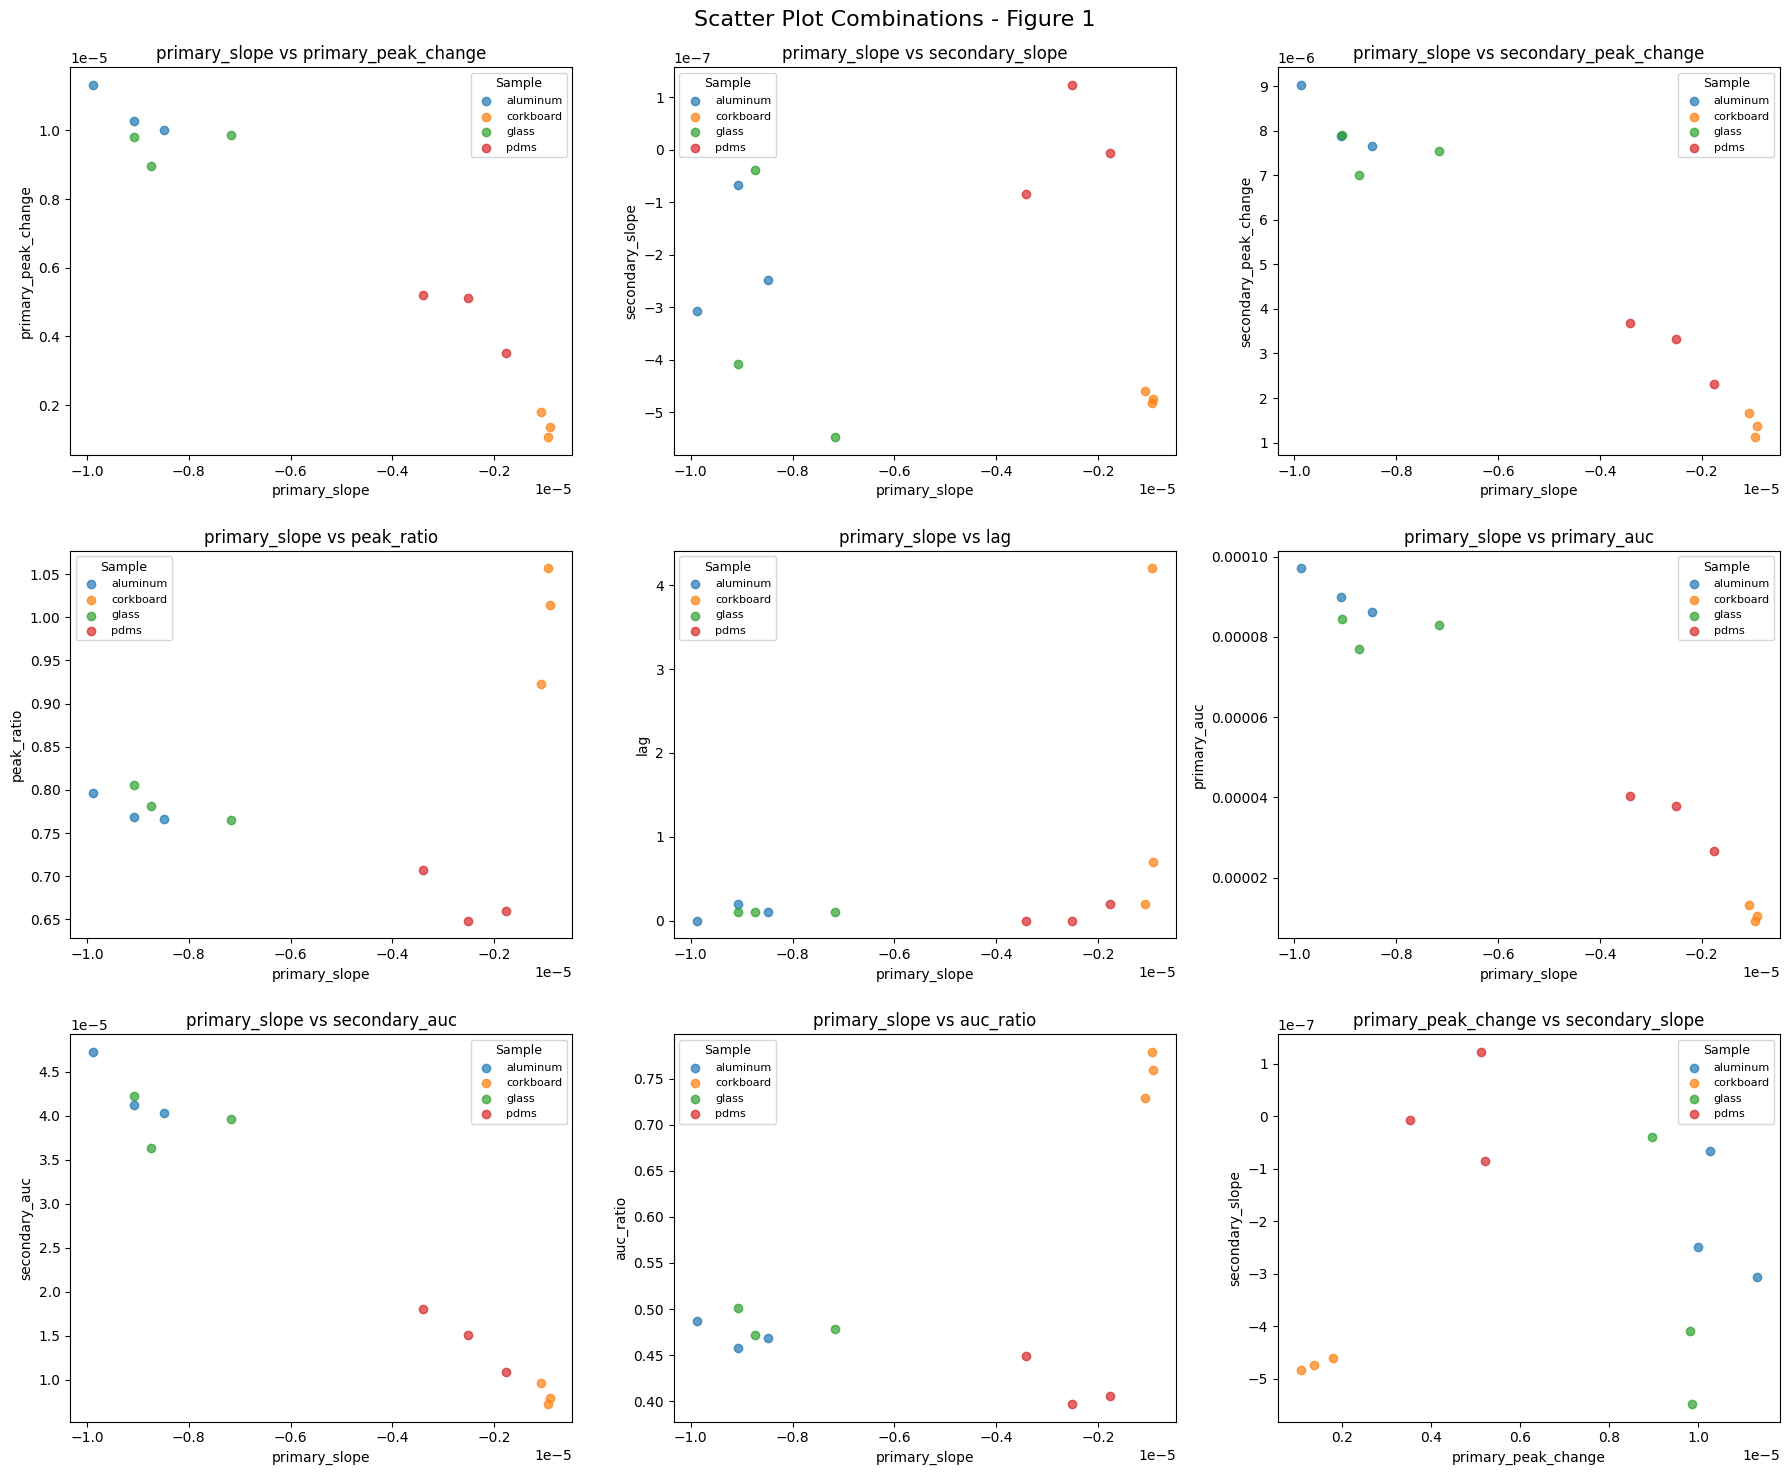

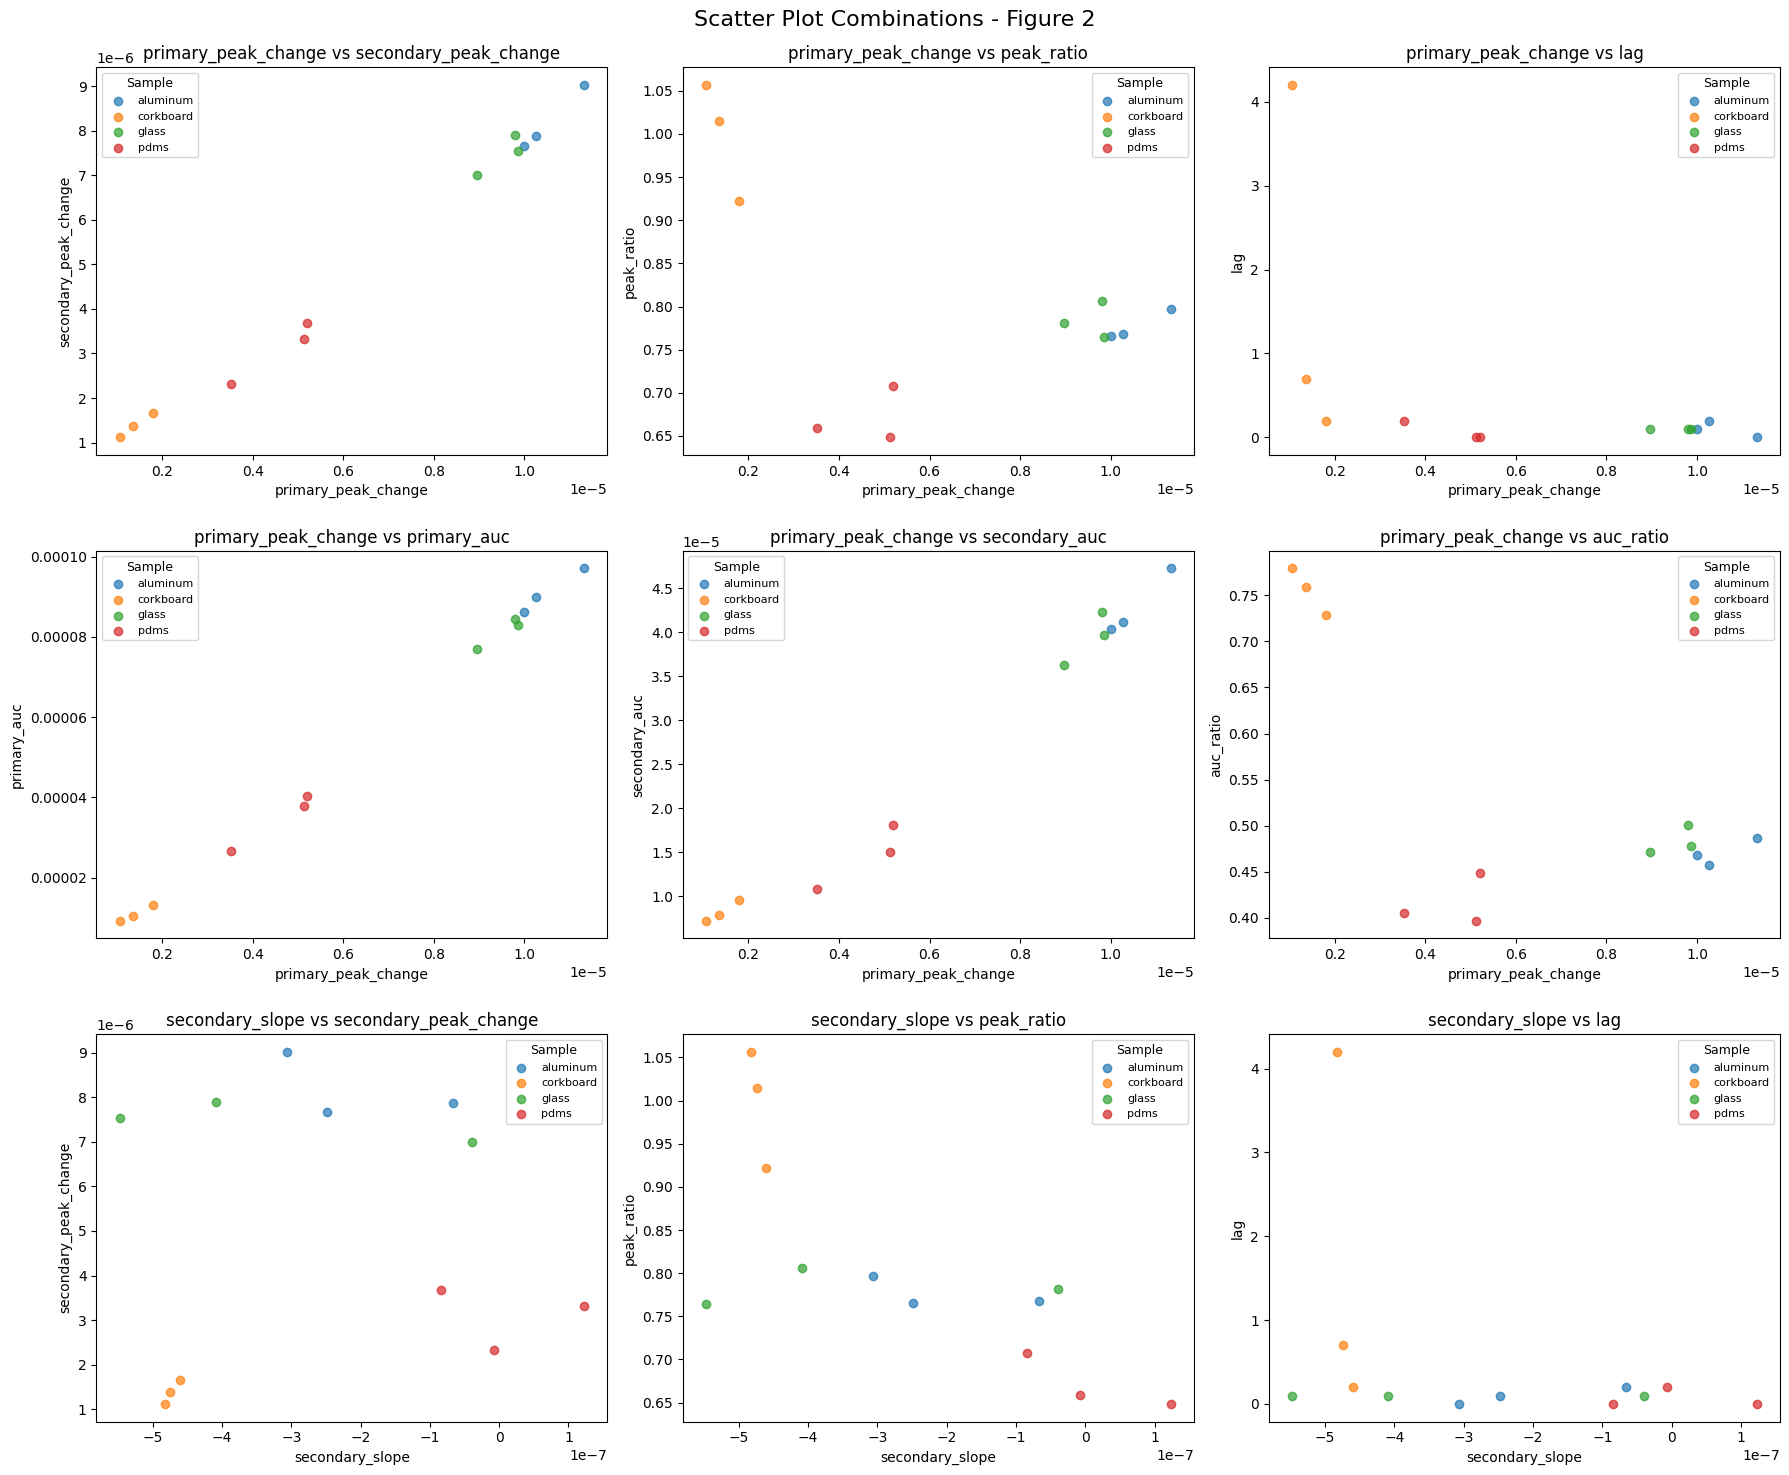

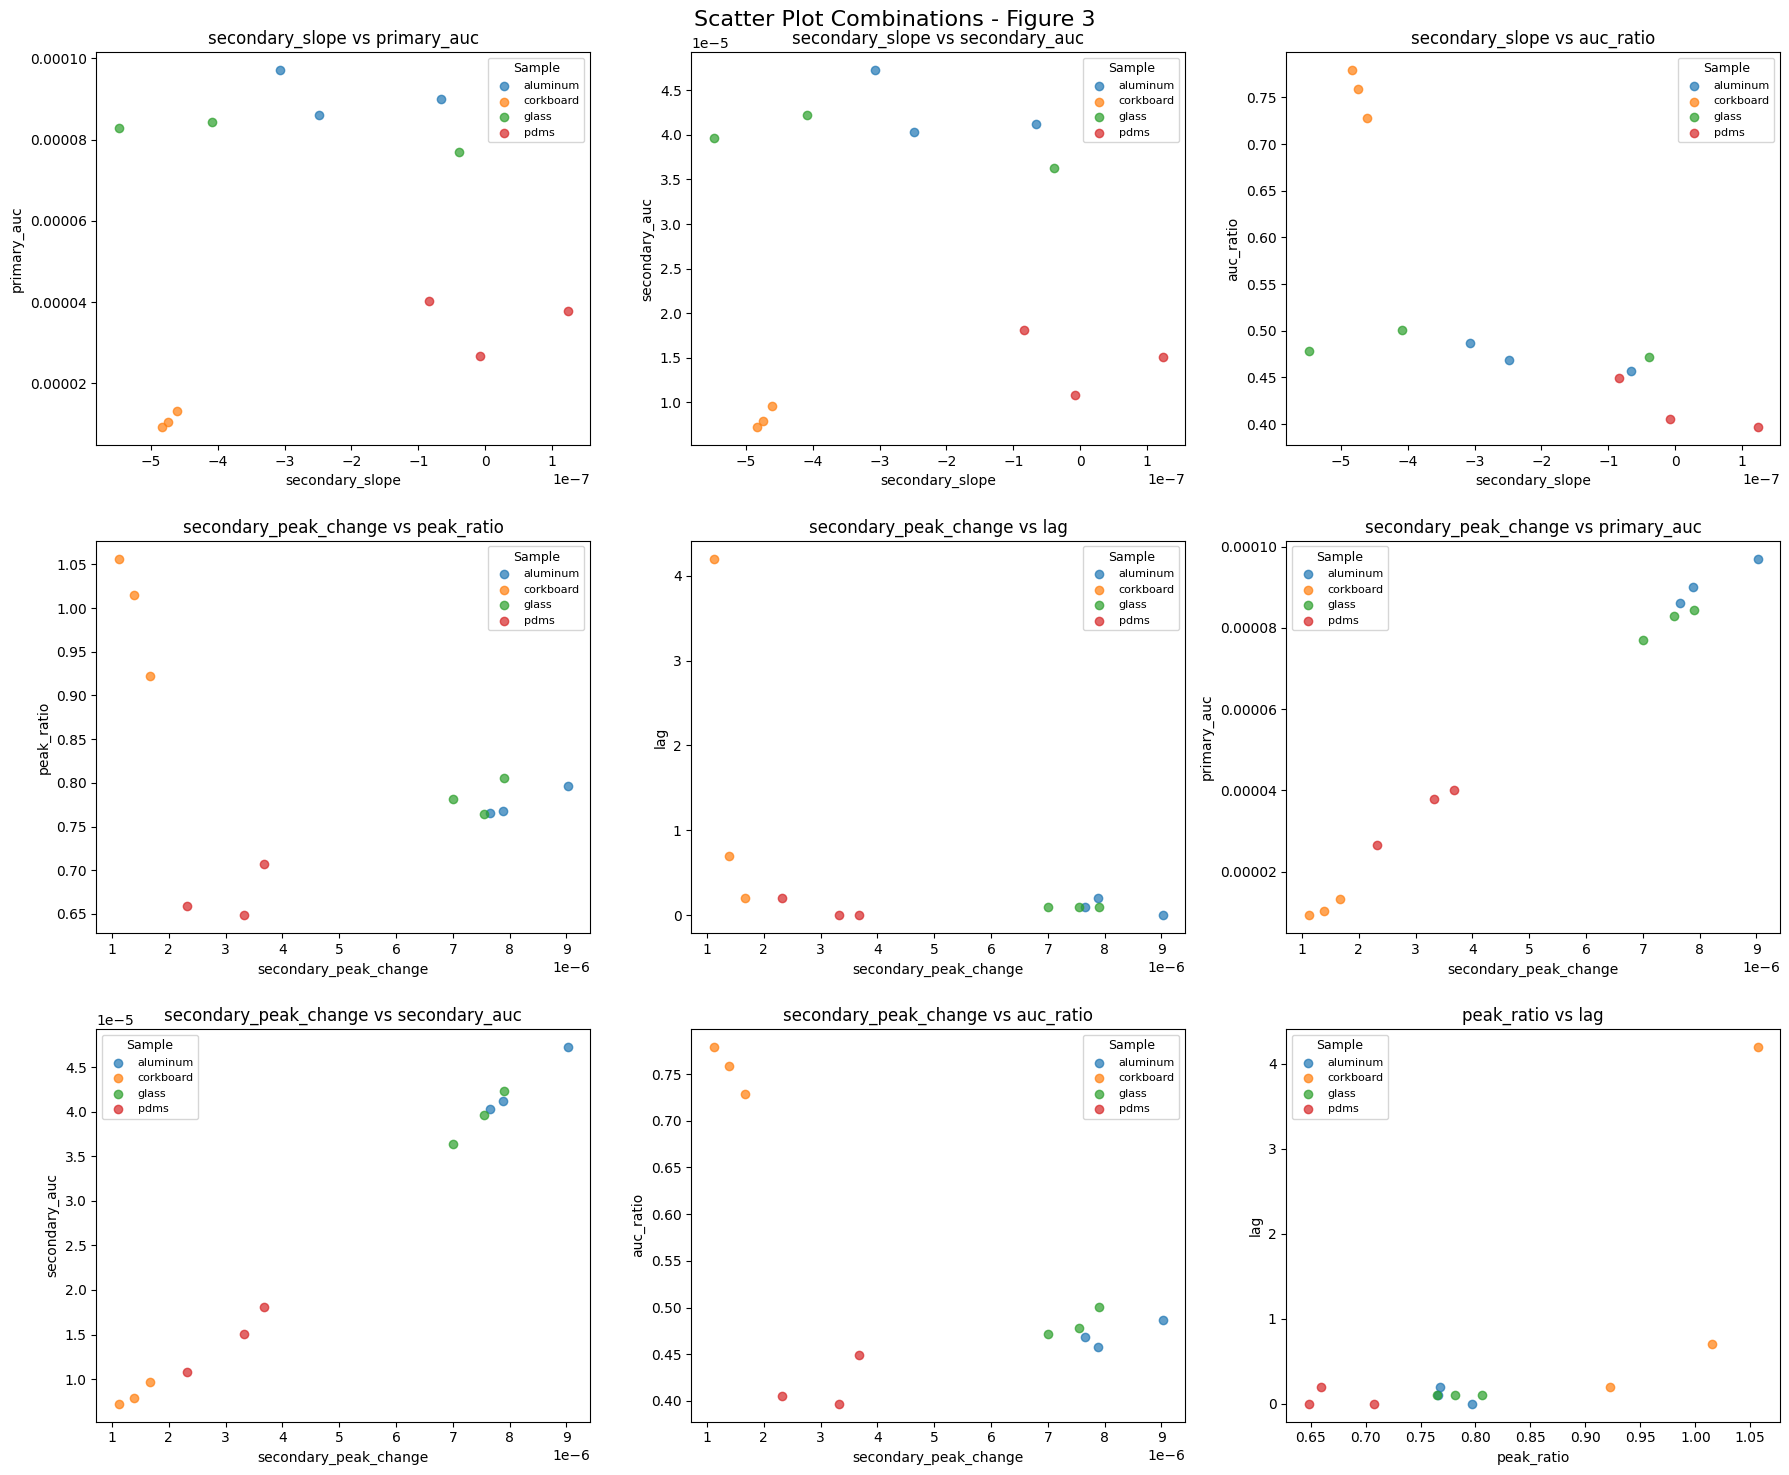

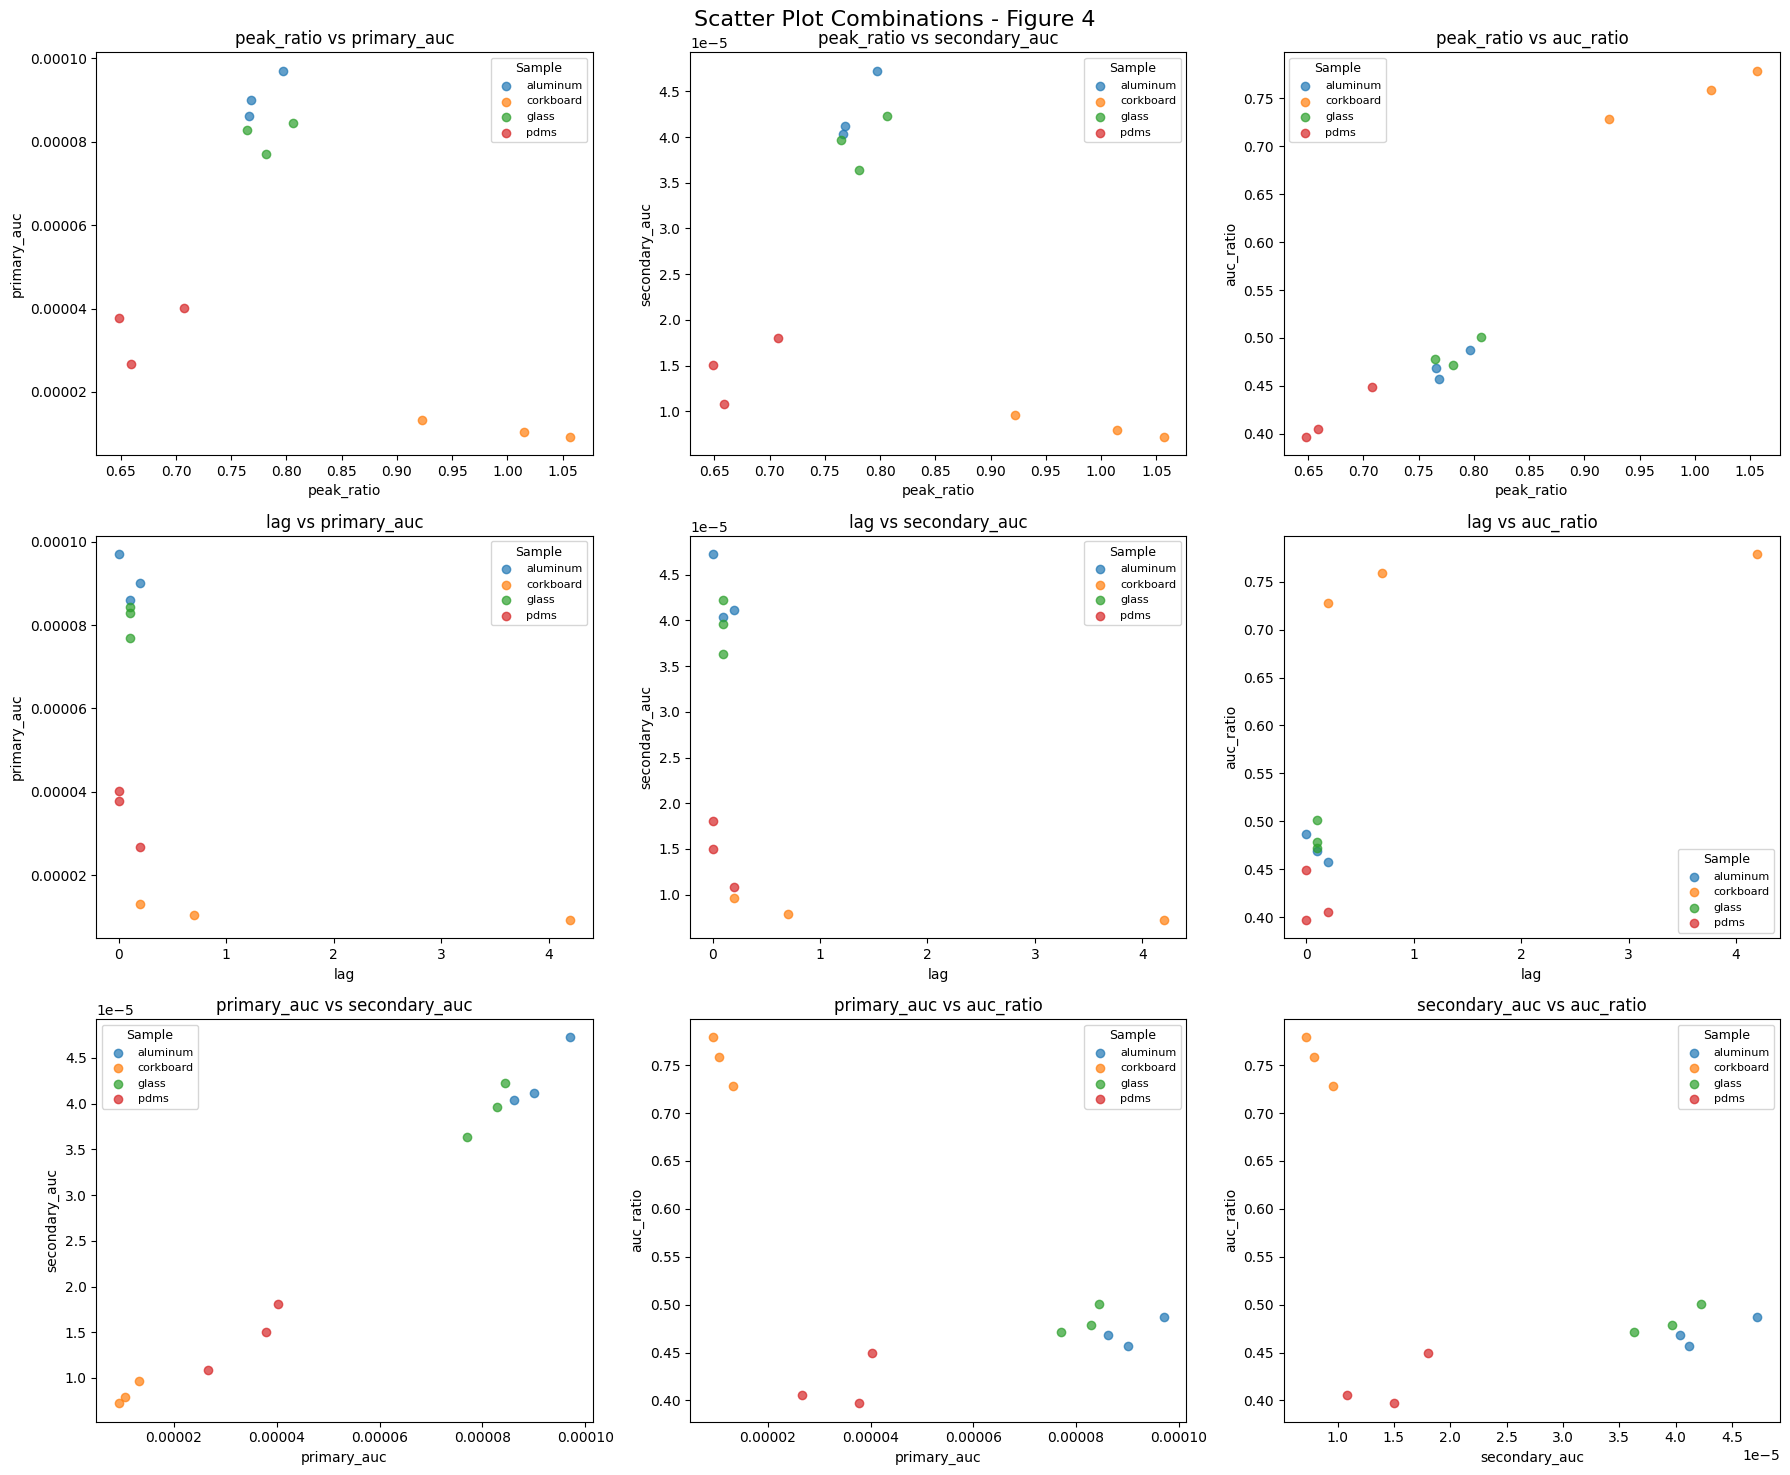

In [506]:
import itertools
import math
import matplotlib.pyplot as plt

pairs = list(itertools.combinations(features, 2))

plots_per_fig = 9
n_cols = 3
n_rows = 3

for fig_num in range(math.ceil(len(pairs) / plots_per_fig)):

    start = fig_num * plots_per_fig
    end = start + plots_per_fig
    current_pairs = pairs[start:end]

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 15))
    axes = axes.flatten()

    for ax, (x_col, y_col) in zip(axes, current_pairs):

        for group, subset in features_df.groupby(legend_col):
            ax.scatter(
                subset[x_col],
                subset[y_col],
                label=group,
                alpha=0.7
            )

        ax.set_xlabel(x_col)
        ax.set_ylabel(y_col)
        ax.set_title(f'{x_col} vs {y_col}')

        ax.legend(
            title=legend_col,
            fontsize=8,
            title_fontsize=9,
            loc='best'
        )

    # hide unused subplots in the last figure
    for ax in axes[len(current_pairs):]:
        ax.axis('off')

    fig.suptitle(f'Scatter Plot Combinations - Figure {fig_num + 1}', fontsize=16)

    plt.tight_layout()
    plt.show()

## Principal Component Analysis

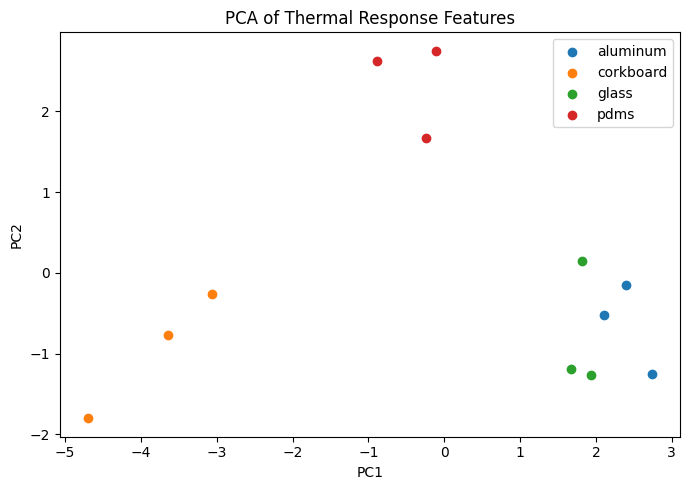

[6.76394841e-01 2.41027180e-01 5.94099744e-02 2.17152289e-02
 8.78658253e-04 4.82297810e-04 6.49936846e-05 2.57522416e-05
 1.07315883e-06]


In [514]:
features_df = features_df.dropna(axis = 1)
X = features_df[features]
y = features_df["Sample"]


X_scaled = StandardScaler().fit_transform(X)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(7, 5))

for m in features_df['Sample'].unique():
    mask = y == m
    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        label=m
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Thermal Response Features")
plt.legend()
plt.tight_layout()
plt.show()

print(pca.explained_variance_ratio_)

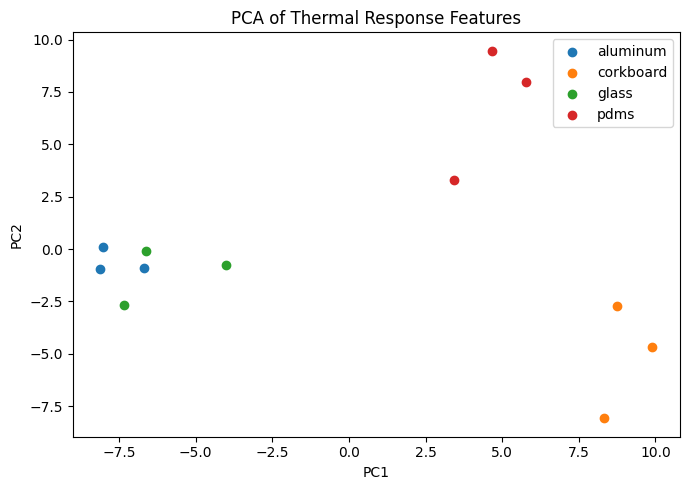

[5.61529785e-01 2.51011666e-01 8.34324219e-02 4.17320377e-02
 2.74979225e-02 1.62413181e-02 6.76274168e-03 5.13931884e-03
 3.33424130e-03 2.03197674e-03 1.28656933e-03 5.68525663e-33]


In [515]:
features_df = features_df.dropna(axis = 1)
X = features_df[features_df.columns[6:]]
y = features_df["Sample"]


X_scaled = StandardScaler().fit_transform(X)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(7, 5))

for m in features_df['Sample'].unique():
    mask = y == m
    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        label=m
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Thermal Response Features")
plt.legend()
plt.tight_layout()
plt.show()

print(pca.explained_variance_ratio_)

## Cumulative Variance Explained

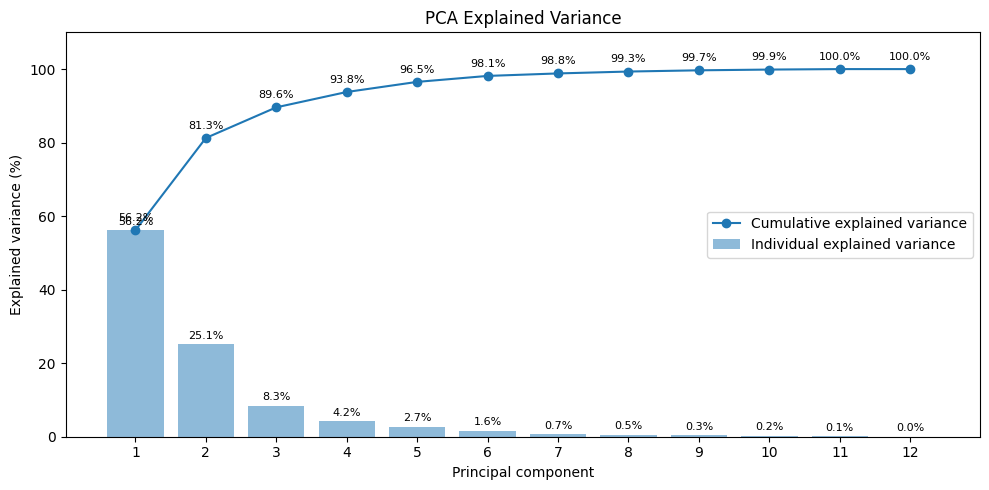

In [516]:
# explained variance
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

x = range(1, len(explained_variance) + 1)

explained_percent = explained_variance * 100
cumulative_percent = cumulative_variance * 100

plt.figure(figsize=(10, 5))

bars = plt.bar(
    x,
    explained_percent,
    alpha=0.5,
    label="Individual explained variance"
)

plt.plot(
    x,
    cumulative_percent,
    marker="o",
    label="Cumulative explained variance"
)

# label individual explained variance bars
for i, value in enumerate(explained_percent, start=1):
    plt.text(
        i,
        value + 1,
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=8
    )

# label cumulative explained variance points
for i, value in enumerate(cumulative_percent, start=1):
    plt.text(
        i,
        value + 2,
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.xlabel("Principal component")
plt.ylabel("Explained variance (%)")
plt.title("PCA Explained Variance")
plt.xticks(x)
plt.ylim(0, 110)
plt.legend()
plt.tight_layout()
plt.show()

# `tsfresh` Feature Extraction

In [541]:
settings = {
    # basic level / magnitude
    "mean": None,
    "median": None,
    "minimum": None,
    "maximum": None,
    "absolute_maximum": None,

    # variability
    "standard_deviation": None,
    "variance": None,
    "root_mean_square": None,
    "mean_abs_change": None,
    "mean_change": None,

    # trend / slope-like behavior
    "linear_trend": [
        {"attr": "slope"},
        {"attr": "intercept"},
        {"attr": "rvalue"},
        {"attr": "pvalue"},
        {"attr": "stderr"}
    ],

    # distribution / shape
    "skewness": None,
    "kurtosis": None,

    # energy / total response
    "abs_energy": None,
    "sum_values": None,

    # temporal dependence
    "autocorrelation": [
        {"lag": 1},
        {"lag": 2},
        {"lag": 5},
        {"lag": 10}
    ],

    # sharp changes / event behavior
    "change_quantiles": [
        {"ql": 0.0, "qh": 0.2, "isabs": False, "f_agg": "mean"},
        {"ql": 0.0, "qh": 0.2, "isabs": True, "f_agg": "mean"},
        {"ql": 0.8, "qh": 1.0, "isabs": False, "f_agg": "mean"},
        {"ql": 0.8, "qh": 1.0, "isabs": True, "f_agg": "mean"}
    ],

    # number of values above/below mean
    "count_above_mean": None,
    "count_below_mean": None,

    # repeated values / stability
    "longest_strike_above_mean": None,
    "longest_strike_below_mean": None,

    # rough complexity
    "cid_ce": [
        {"normalize": True},
        {"normalize": False}
    ]
}

In [542]:
# use only filtered data
ts_data = data[(data["filter"]) & (data['Sample'] != 'steel')].copy()

# create one ID per material-trial
ts_data["id"] = (
    ts_data["Sample"].astype(str) +
    "_trial_" +
    ts_data["Trial"].astype(int).astype(str)
)

# primary sensor table
primary = ts_data[[
    "id",
    "Time",
    "Primary"
]].copy()

primary = primary.rename(columns={
    "Time": "time",
    "Primary": "value"
})

primary["kind"] = "Primary"

# secondary sensor table
secondary = ts_data[[
    "id",
    "Time",
    "Secondary"
]].copy()

secondary = secondary.rename(columns={
    "Time": "time",
    "Secondary": "value"
})

secondary["kind"] = "Secondary"


# diff sensor table
diff = ts_data[[
    "id",
    "Time",
    "diff"
]].copy()

diff = diff.rename(columns={
    "Time": "time",
    "diff": "value"
})

diff["kind"] = "Difference"

# combine primary and secondary
tsfresh_input = pd.concat(
    [primary, secondary, diff],
    ignore_index=True
)

tsfresh_input = tsfresh_input[[
    "id",
    "time",
    "kind",
    "value"
]]

# clean invalid values
tsfresh_input = tsfresh_input.replace([np.inf, -np.inf], np.nan)
tsfresh_input = tsfresh_input.dropna()

tsfresh_input.head()

,id,time,kind,value
0,glass_trial_1,0.00000,Primary,0.000659
1,glass_trial_1,0.10000,Primary,0.000659
2,glass_trial_1,0.20000,Primary,0.000658
3,glass_trial_1,0.30000,Primary,0.000658
4,glass_trial_1,0.39996,Primary,0.000657


In [543]:
tsfresh_features = extract_features(
    tsfresh_input,
    column_id="id",
    column_sort="time",
    column_kind="kind",
    column_value="value",
    default_fc_parameters=settings,
    n_jobs=0
)

Feature Extraction: 100%|██████████| 36/36 [00:00<00:00, 639.34it/s]


In [544]:
labels = (
    ts_data[["id", "Sample", "Trial"]]
    .drop_duplicates()
    .set_index("id")
)
tsfresh_features = tsfresh_features.dropna(axis=1)


tsfresh_features = tsfresh_features.join(labels)
tsfresh_features = tsfresh_features.reset_index()
tsfresh_features.head()

,index,Difference__mean,Difference__median,Difference__minimum,Difference__maximum,Difference__absolute_maximum,Difference__standard_deviation,Difference__variance,Difference__root_mean_square,Difference__mean_abs_change,...,"Secondary__change_quantiles__f_agg_""mean""__isabs_False__qh_1.0__ql_0.8","Secondary__change_quantiles__f_agg_""mean""__isabs_True__qh_1.0__ql_0.8",Secondary__count_above_mean,Secondary__count_below_mean,Secondary__longest_strike_above_mean,Secondary__longest_strike_below_mean,Secondary__cid_ce__normalize_True,Secondary__cid_ce__normalize_False,Sample,Trial
0,aluminum_trial_1,0.000045,0.000045,0.000040,0.000048,0.000048,1.923034e-06,3.698059e-12,0.000045,1.367677e-07,...,-6.105263e-08,6.947368e-08,46.0,54.0,46.0,54.0,0.340422,1.016464e-06,aluminum,1.0
1,aluminum_trial_2,0.000044,0.000044,0.000039,0.000046,0.000046,1.634832e-06,2.672676e-12,0.000044,1.208081e-07,...,-5.263158e-08,7.368421e-08,46.0,54.0,46.0,54.0,0.355382,9.017760e-07,aluminum,2.0
2,aluminum_trial_3,0.000044,0.000044,0.000040,0.000047,0.000047,1.788654e-06,3.199284e-12,0.000044,1.298990e-07,...,-4.947368e-08,5.789474e-08,45.0,55.0,45.0,55.0,0.335849,8.944272e-07,aluminum,3.0
3,corkboard_trial_1,0.000040,0.000040,0.000039,0.000040,0.000040,1.803326e-07,3.251984e-14,0.000040,3.272727e-08,...,-1.777778e-08,2.444444e-08,47.0,53.0,47.0,53.0,0.962243,4.377214e-07,corkboard,1.0
4,corkboard_trial_2,0.000040,0.000040,0.000039,0.000040,0.000040,2.046870e-07,4.189676e-14,0.000040,3.515152e-08,...,-5.555556e-09,2.777778e-08,48.0,52.0,48.0,52.0,1.803611,6.493073e-07,corkboard,2.0


## Principal Component Analysis

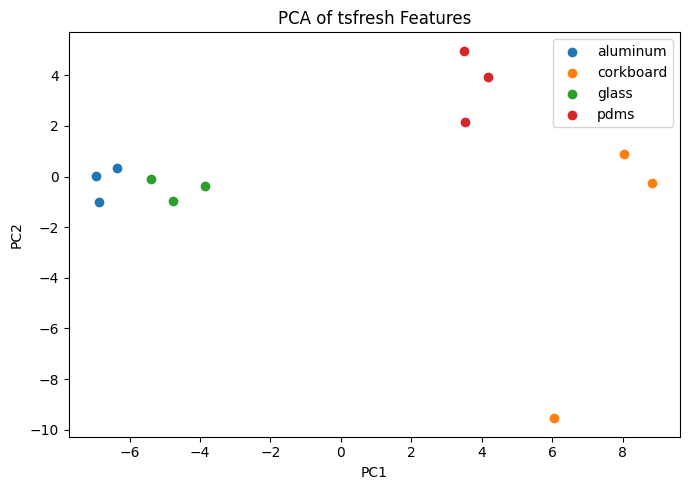

[6.09219519e-01 1.99826669e-01 1.16695240e-01 2.87985228e-02
 2.44067672e-02 9.04465566e-03 6.44545055e-03 2.39834444e-03
 1.78168812e-03 8.56513987e-04 5.26628965e-04 3.88229393e-33]


In [545]:
feature_cols = tsfresh_features.drop(columns=["index", "Sample", "Trial"]).columns
feature_cols = [c for c in feature_cols if 'Difference' not in c]

X = tsfresh_features[feature_cols]
y = tsfresh_features["Sample"]

X_scaled = StandardScaler().fit_transform(X)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(7, 5))

for m in y.unique():
    mask = y == m
    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        label=m
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of tsfresh Features")
plt.legend()
plt.tight_layout()
plt.show()

print(pca.explained_variance_ratio_)

## Cumulative Variance Explained

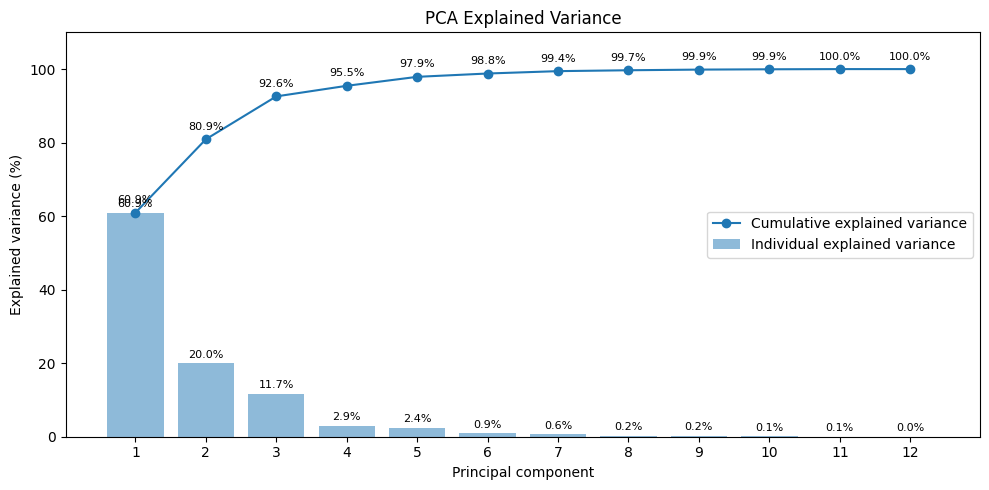

In [546]:
# explained variance
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

x = range(1, len(explained_variance) + 1)

explained_percent = explained_variance * 100
cumulative_percent = cumulative_variance * 100

plt.figure(figsize=(10, 5))

bars = plt.bar(
    x,
    explained_percent,
    alpha=0.5,
    label="Individual explained variance"
)

plt.plot(
    x,
    cumulative_percent,
    marker="o",
    label="Cumulative explained variance"
)

# label individual explained variance bars
for i, value in enumerate(explained_percent, start=1):
    plt.text(
        i,
        value + 1,
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=8
    )

# label cumulative explained variance points
for i, value in enumerate(cumulative_percent, start=1):
    plt.text(
        i,
        value + 2,
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.xlabel("Principal component")
plt.ylabel("Explained variance (%)")
plt.title("PCA Explained Variance")
plt.xticks(x)
plt.ylim(0, 110)
plt.legend()
plt.tight_layout()
plt.show()

# Reservoir Computing

In [547]:
rc_data = data[(data["filter"]) & (data['Sample'] != 'steel')].copy()
rc_data = rc_data.sort_values(["Sample", "Trial", "Time"])

length_check = (
    rc_data
    .groupby(["Sample", "Trial"])
    .size()
    .reset_index(name="n_points")
)

min_len = length_check["n_points"].min()

X_list = []
y_list = []

for (sample, trial), subset in rc_data.groupby(["Sample", "Trial"]):

    subset = subset.sort_values("Time").head(min_len)

    sequence = subset[[
        "Primary",
        "Secondary"
    ]].values

    X_list.append(sequence)
    y_list.append(sample)

X = X_list
y = np.array(y_list)

print(len(X))
print(X[0].shape)
print(y.shape)


le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(le.classes_)
print(y_encoded)

12
(100, 2)
(12,)
['aluminum' 'corkboard' 'glass' 'pdms']
[0 0 0 1 1 1 2 2 2 3 3 3]


In [548]:
X_rc = []

for sequence in X:

    reservoir = Reservoir(
        units=50,
        sr=0.9,
        lr=0.3,
        input_scaling=0.5,
        seed=42
    )

    states = reservoir.run(sequence)

    features = np.concatenate([
        states.mean(axis=0),
        states.std(axis=0),
        states[-1, :]
    ])

    X_rc.append(features)

X_rc = np.array(X_rc)

print(X_rc.shape)

(12, 150)


## Principal Component Analysis

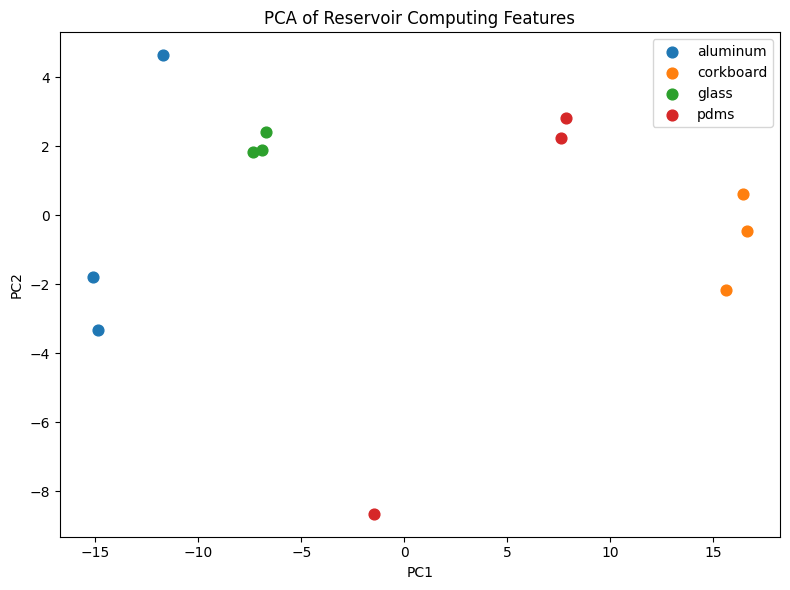

In [551]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_rc)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

materials = np.unique(y)

plt.figure(figsize=(8, 6))

for m in materials:
    mask = y == m

    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        label=m,
        s=60
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Reservoir Computing Features")
plt.legend()
plt.tight_layout()
plt.show()

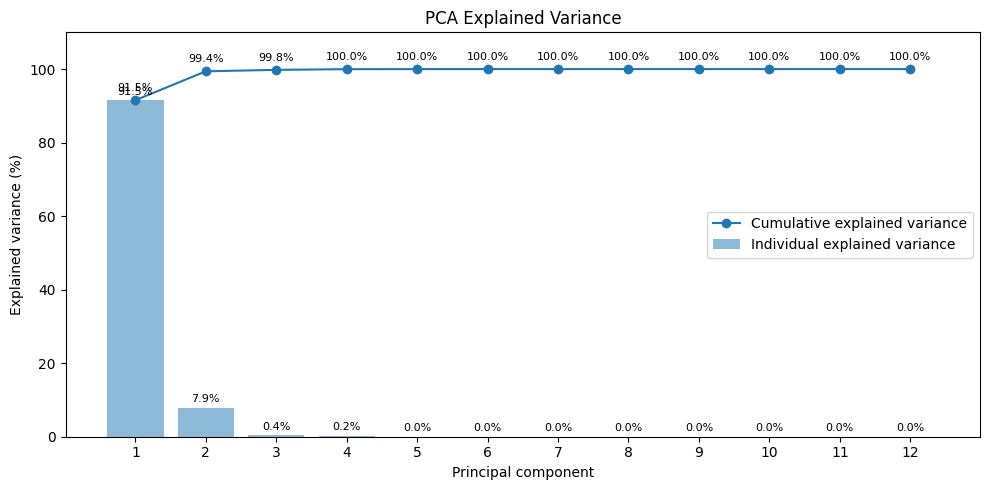

In [552]:
# explained variance
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

x = range(1, len(explained_variance) + 1)

explained_percent = explained_variance * 100
cumulative_percent = cumulative_variance * 100

plt.figure(figsize=(10, 5))

bars = plt.bar(
    x,
    explained_percent,
    alpha=0.5,
    label="Individual explained variance"
)

plt.plot(
    x,
    cumulative_percent,
    marker="o",
    label="Cumulative explained variance"
)

# label individual explained variance bars
for i, value in enumerate(explained_percent, start=1):
    plt.text(
        i,
        value + 1,
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=8
    )

# label cumulative explained variance points
for i, value in enumerate(cumulative_percent, start=1):
    plt.text(
        i,
        value + 2,
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.xlabel("Principal component")
plt.ylabel("Explained variance (%)")
plt.title("PCA Explained Variance")
plt.xticks(x)
plt.ylim(0, 110)
plt.legend()
plt.tight_layout()
plt.show()